In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

In [2]:
!Pip install lightkurve
!Pip install oktopus

In [3]:
"""
The IO module contains the primary methods for PBjam to process either a time
series or power density spectrum from the user or an automatically downloaded 
data set from the Mikulski Archive for Spact Telescopes (https://archive.stsci.edu/home) 
via the Lightkurve package.
"""

import jax.numpy as jnp
import numpy as np
from scipy.integrate import simpson
import time
import lightkurve as lk
from lightkurve.periodogram import Periodogram
from astropy.timeseries import LombScargle
from astropy import units
 
 
class psd():
    """Asteroseismology wrapper for Astropy Lomb-Scargle

    Uses the Astropy.LombScargle class to compute the power spectrum of a given 
    time series. A variety of choices for computing the spectrum are available. 
    The recommended methods are either 'fast' or 'Cython'.

    Notes
    -----
    The Cython implementation is very slow for time series longer than about 1 month 
    (array size of ~1e5). The Fast implementation is similar to the an FFT, but at a 
    very slight loss of accuracy. There appears to be a slight increasing slope with 
    frequency toward the Nyquist frequency.

    The adjustments to the frequency resolution, due to gaps, performed in the KASOC 
    filter may not be beneficial the statistics we use in the detection algorithm.  
    This has not been thuroughly tested yet though. So recommend leaving it in, but 
    with a switch to turn it off for testing.

    Parameters
    ----------
    ID : str
        Target ID. Used to look up the target on MAST if time/flux is not provided. 
    lk_kwargs : dict, optional
        Dictionary of arguments to pass to Lightkurve for looking up targets. Leave
        this blank if providing time/flux 
    time : array, optional
        Time stamps of the time series. If this is provided Lightkurve will not be
        used to download the data.
    flux : array, optional
        Flux values of the time series. If this is provided Lightkurve will not be
        used to download the data.
    flux_error : array, optional
        Flux value errors of the time series.
    fit_mean : bool, optional
        Keyword for Astropy.LombScargle. If True, uses the generalized Lomb-Scargle 
        approach and fits with a floating mean. Default is False.
    timeConversion : float, optional
        Factor to convert the time series such that it is in seconds. Note, all stored 
        time values, e.g. cadence or duration, are kept in the input units. Default is 
        86400 s/day to convert from days to seconds.

    Attributes
    ----------
    dt : float
        Cadence of the time series.
    dT : float
        Total length of the time series.
    NT : int
        Number of data points in the time series.
    dutyCycle : float
        Duty cycle of the time series.
    Nyquist : float
        Nyquist frequency in Hz.
    df : float
        Fundamental frequency spacing in Hz.
    ls : astropy.timeseries.LombScargle object:
        Astropy Lomb-Scargle class instance used in computing the power spectrum.
    freqHz : array, float
        Frequency range in Hz.
    freq : array, float
        Freqeuency range in muHz.
    normfactor : float
        Normalization factor to ensure the power conforms with Parseval.
    power : array, float
        Power spectrum of the time series in ppm^2.
    powerdensity : array float
        Power density spectrum of the time series in ppm^2/muHz
    amplitude : array, float
        Amplitude spectrum of the time series in ppm.
    """
    
    def __init__(self, ID, lk_kwargs={}, time=None, flux=None, flux_err=None, useWeighted=False, 
                 downloadDir=None, fit_mean=False, timeConversion=86400, badIdx=None, numax=None):
 
        self.__dict__.update((k, v) for k, v in locals().items() if k not in ['self'])

        self.TS = timeSeries(ID, lk_kwargs, time, flux, flux_err, self.badIdx, self.downloadDir, numax=self.numax)
                          
        if useWeighted:
            # Init Astropy LS class with weights
            assert flux_err is not None, 'To compute the weighted spectrum, provide a flux_err argument.'

            self.ls = LombScargle(self.TS.time * self.timeConversion,
                                  self.TS.flux, center_data=True,
                                  fit_mean=self.fit_mean,
                                  dy=self.TS.flux_err,)
        else:
            # Init Astropy LS class without weights
            self.ls = LombScargle(self.TS.time * self.timeConversion,
                                    self.TS.flux, center_data=True,
                                    fit_mean=self.fit_mean)
   
        self.Nyquist = 1/(2 * self.timeConversion * self.TS.dt) # Hz

        self.df = self._fundamental_spacing_integral()
 
    def __call__(self, oversampling=1, nyquist_factor=1.0, method='fast'):
        """ Compute power spectrum

        Computes the power spectrum and normalizes it to conform with Parseval's
        theorem. The output is available as the power in ppm^2, powerdensity in
        ppm^2/muHz and the amplitude spectrum in ppm.

        The frequency range is transformed to muHz as this is customarily used
        in asteroseismology of main sequence stars.

        Parameters
        ----------
        oversampling : int
            The number of times the frequency range should be oversampled. This
            equates to zero-padding when using the FFT.
        nyquist_factor : float
            Factor by which to extend the spectrum past the Nyquist frequency.
            The default is 10% greater than the true Nyquist frequency. We use
            this to get a better handle on the background level at high
            frequency.
        method : str
            The recommended methods are either `fast' or `Cython'. Cython is
            a bit more accurate, but significantly slower.
        """

        self.freqHz = np.arange(self.df/oversampling, nyquist_factor*self.Nyquist, 
                                self.df/oversampling, dtype='float64')

        self.freq = jnp.array(self.freqHz*1e6) # muHz is usually used in seismology

        # Calculate power at frequencies using fast Lomb-Scargle periodogram:
        power = self.ls.power(self.freqHz, normalization='psd', method=method, 
                              assume_regular_frequency=True)

        # Due to numerical errors, the "fast implementation" can return power < 0.
        # Replace with random exponential values instead of 0?
        power = np.clip(power, 0, None)

        self._getNorm(power)

        self.power = jnp.array(power * self.normfactor * 2)

        self.powerdensity = jnp.array(power * self.normfactor / (self.df * 1e6))
 
        self.amplitude = jnp.array(power * np.sqrt(power * self.normfactor * 2))        

        pg = Periodogram(self.freq * units.uHz, units.Quantity(self.powerdensity))
 
        self.pg = pg

    def getTSWindowFunction(self, tmin=None, tmax=None, cadenceMargin=1.01):
        """
        Generates a time series window function.

        Parameters
        ----------
        tmin : float, optional
            Minimum time value for padding. If None, uses the minimum of self.time. 
            Default is None.
        tmax : float, optional
            Maximum time value for padding. If None, uses the maximum of self.time. 
            Default is None.
        cadenceMargin : float, optional
            Margin factor to identify gaps in the time series. Default is 1.01.

        Returns
        -------
        tuple
            A tuple containing the adjusted time array and the corresponding window 
            function array.

        Notes
        -----
        - The method first initializes the time (`t`) and window function (`w`) arrays.
        - It then identifies gaps in the time series larger than `cadenceMargin * self.dt` 
        and fills them with zeros in the window function.
        - The method ensures the length of the time series does not exceed a break counter 
        of 100 to avoid infinite loops.
        - Padding is added at the start and end of the time series if `tmin` or `tmax` are 
        specified and exceed the current bounds of `t`.
        """

        if tmin is None:
            tmin = min(self.TS.time)

        if tmax is None:
            tmax = max(self.TS.time)

        t = self.TS.time.copy() 

        w = np.ones_like(t)

        break_counter = 0

        epsilon = 0.0001 # this is a tiny scaling of dt to avoid numerical issues

        while any(np.diff(t) > cadenceMargin * self.TS.dt):

            idx = np.where(np.diff(t)>cadenceMargin*self.TS.dt)[0][0]

            t_gap_fill = np.arange(t[idx], t[idx+1]-epsilon*self.TS.dt, self.TS.dt)

            w_gap_fill = np.zeros(len(t_gap_fill))

            w_gap_fill[0] = 1

            t = np.concatenate((t[:idx], t_gap_fill, t[idx+1:]))

            w = np.concatenate((w[:idx], w_gap_fill, w[idx+1:]))

            break_counter +=1

            if break_counter == 100:
                break

        if (tmin is not None) and (tmin < t[0]):
            padLow = np.arange(tmin, t[0], self.TS.dt)

            t = np.append(padLow, t)
            
            w = np.append(np.zeros_like(padLow), w)

        if (tmax is not None) and (t[0] < tmax):
            padHi = np.arange(t[-1], tmax, self.TS.dt)
            
            t = np.append(t, padHi)
            
            w = np.append(w, np.zeros_like(padHi))

        return t, w

    def _getNorm(self, power):
        """ Parseval normalization

        Computes the normalization factor for the power spectrum such that it
        conforms with Parseval's theorem.

        power : array
            Unnormalized array of power.
        """

        N = len(self.ls.t)

        if self.ls.dy is None:
            tot_MS = np.sum((self.ls.y - np.nanmean(self.ls.y))**2)/N
        else:
            tot_MS = np.sum(((self.ls.y - np.nanmean(self.ls.y))/self.ls.dy)**2)/np.sum((1/self.ls.dy)**2)

        self.normfactor = tot_MS/np.sum(power)

    def _fundamental_spacing_integral(self):
        """ Estimate fundamental frequency bin spacing

        Computes the frequency bin spacing using the integral of the spectral
        window function.

        For uniformly sampled data this is given by df=1/T. Which under ideal
        circumstances ensures that power in neighbouring frequency bins is
        independent. However, this fails when there are gaps in the time series.
        The integral of the spectral window function is a better approximation
        for ensuring the bins are less correlated.

        """

        # The nominal frequency resolution
        df = 1/(self.timeConversion*(np.nanmax(self.TS.time) - np.nanmin(self.TS.time))) # Hz

        # Compute the window function
        freq, window = self.windowfunction(df, width=100*df, oversampling=5) # oversampling for integral accuracy

        # Integrate the windowfunction to get the corrected frequency resolution
        df = simpson(window, x=freq)

        return df*1e-6

    def windowfunction(self, df, width=None, oversampling=10):
        """Spectral window function.

        Parameters
        ----------
        width : float, optional
            The width in Hz on either side of zero to calculate spectral window. Default is None.
        oversampling : float, optional
            Oversampling factor. Default is 10.
        """
         
        if width is None:
            width = 100*df

        # freq_cen = 0.5*self.Nyquist
        freq_cen = max([0.5*self.Nyquist, width + df])
        
        Nfreq = int(oversampling*width/df)

        freq = freq_cen + (df/oversampling) * np.arange(-Nfreq, Nfreq, 1)

        x = 0.5*np.sin(2*np.pi*freq_cen*self.ls.t) + 0.5*np.cos(2*np.pi*freq_cen*self.ls.t)

        # Calculate power spectrum for the given frequency range:
        ls = LombScargle(self.ls.t, x, center_data=True, fit_mean=self.fit_mean)

        power = ls.power(freq, method='fast', normalization='psd', assume_regular_frequency=True)

        power /= power[int(len(power)/2)] # Normalize to have maximum of one

        freq -= freq_cen

        freq *= 1e6

        return freq, power

class timeSeries():

    def __init__(self, ID, lk_kwargs, time, flux, flux_err=None, badIdx=None, downloadDir=None, numax=None):
        
        self.__dict__.update((k, v) for k, v in locals().items() if k not in ['self'])
        
        if (self.time is None) and (self.flux is None):

            self.time, self.flux, self.flux_err = self._getTS()

            self.flux = (self.flux/np.nanmedian(self.flux) - 1) * 1e6

        self._getBadIndex(self.time, self.flux, self.flux_err, self.badIdx)

        self.goodIdx = np.invert(self.badIdx)

        self.time, self.flux = self.time[self.goodIdx], self.flux[self.goodIdx]

        if self.flux_err is not None:
            self.flux_err = self.flux_err[self.goodIdx]
        
        self.dt = self._getSampling()

        self.dT = self.time.max() - self.time.min()

        self.NT = len(self.time)

        self.dutyCycle = self._getDutyCycle()

    def _getDutyCycle(self, cadence=None):
        """ Compute the duty cycle

        If cadence is not provided, it is assumed to be the median difference
        of the time stamps in the time series.

        Parameters
        ----------
        cadence : float
            Nominal cadence of the time series. Units should be the
            same as t.

        Returns
        -------
        dutyCycle : float
            Duty cycle of the time series
        """

        if cadence is None:
            cadence = self._getSampling()

        nomLen = np.ceil((np.nanmax(self.time) - np.nanmin(self.time)) / cadence)
 
        dutyCycle = len(self.time) / nomLen

        return dutyCycle
    
    def _getBadIndex(self, time, flux, flux_err, badIdx):
        """ Identify indices with nan/inf values

        Flags array indices where either the timestamps, flux values, or flux errors
        are nan or inf.
        """

        if badIdx is None:
            badIdx = np.zeros(len(time), dtype=bool)
        
        if flux_err is None:
            flux_err = np.zeros(len(time), dtype=bool)
        
        self.badIdx = np.invert(np.isfinite(time) & np.isfinite(flux) & np.isfinite(flux_err) & np.invert(badIdx)) 
        
    def _getSampling(self):
        """ Compute sampling rate

        Computes the average sampling rate in the time series.

        This should approximate the nominal sampling rate,
        even with gaps in the time series.

        Returns
        ----------
        dt : float
            Cadence of the time stamps.
        """
         
        dt = np.median(np.diff(self.time))

        return dt
    
    def _getTS(self, outlierRejection=5):
        """Get time series with lightkurve

        Parameters
        ----------
        outlierRejection : float, optional
            Number of sigma to use for sigma clipping in the time series cleaning.
            Used as input the the lightkurve remove_outliers method.

        Returns
        -------
        time : DeviceArray
            The timestamps of the time series.
        flux : DeviceArray
            The flux values of the time series.
        """
        
        # Force a short wait time to prevent multiple rapid requests from 
        # being rejected.
        time.sleep(np.random.uniform(1, 5))

        search = lk.search_lightcurve(self.ID, **self.lk_kwargs)
        
        LCcol = search.download_all(download_dir=self.downloadDir)

        lc = LCcol.stitch()
              
        lc = self.cleanLC(lc, outlierRejection)

        _time, _flux, _flux_err = jnp.array(lc.time.value), jnp.array(lc.flux.value), jnp.array(lc.flux_err.value)
 
        return _time, _flux, _flux_err
    
    def cleanLC(self, lc, outlierRejection):
        """ Perform Lightkurve operations on object.

        Performs basic cleaning of a light curve, removing nans, outliers,
        median filtering etc.

        Parameters
        ----------
        lc : Lightkurve.LightCurve instance
            Lightkurve object to be cleaned
        outlierRejection : float, optional
            Number of sigma to use for sigma clipping in the time series cleaning.
            Used as input the the lightkurve remove_outliers method.

        Returns
        -------
        lc : Lightkurve.LightCurve instance
            The cleaned Lightkurve object
        """

        if self.numax is None:
            wlen = int(4e6 / self.lk_kwargs['exptime'])
        else:
            wlen = int(1/(self.numax * 1e-3)*1e6 / self.lk_kwargs['exptime'])

        if wlen % 2 == 0:
            wlen += 1
            
        lc = lc.normalize().remove_nans().remove_outliers(outlierRejection).flatten(window_length=wlen) #remove_nans().flatten(window_length=4001).remove_outliers()

        return lc

In [4]:
def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_low, noise_high):
    signals=[]
    for i in tqdm(range(0, N)):
        noise_lvl = np.random.uniform(noise_low, noise_high)
        fake_base = [noise_lvl] * len(freqs)
        fake_signal = random(fake_base)
        signals.append(fake_signal)
    
    # Convert the whole thing to a NumPy array before returning
    return np.array(signals)

In [5]:
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772


In [6]:
def get_mode_envelope_mask(freq, power, delta_nu_est, numax_est):

    nu_max = numax_est
    fwhm_env = 0.66 * (nu_max ** 0.88)
    sigma_env = fwhm_env / 2.355

    lower = max(0, nu_max - 4 * sigma_env)
    upper = nu_max + 4 * sigma_env

    mask = (freq >= lower) & (freq <= upper)

    return freq[mask], power[mask]


In [7]:
def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.2):

    main_lo = delta_nu_est * (1 - window_frac)
    main_hi = delta_nu_est * (1 + window_frac)

    half_lo = 0.5 * delta_nu_est * (1 - window_frac)
    half_hi = 0.5 * delta_nu_est * (1 + window_frac)

    three_half_lo = 1.5 * delta_nu_est * (1 - window_frac)
    three_half_hi = 1.5 * delta_nu_est * (1 + window_frac)

    mask = (
        (lags > main_lo) & (lags < main_hi) &
        ~((lags > half_lo) & (lags < half_hi)) &
        ~((lags > three_half_lo) & (lags < three_half_hi))
    )

    return lags[mask], acf[mask]


In [8]:
import numpy as np
from scipy.ndimage import uniform_filter1d
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c


In [9]:
#DEFINE SCALING RELATION
    
def delta_nu_from_numax(numax):
    return 0.263 * numax**0.772
    


def sliding_acf_search(frequency, #frequency array
                       power_flat, #flattened power spectrum
                       numax_grid, #array of values of nu_max to run autocorrelation around
                       k_width=4.0, #width of each window as a multiple of delta_nu
                       lag_frac=(0.8, 1.2) 
                      ):
    
    acf_strength = []
    df = frequency[1] - frequency[0]
    for nu_c in numax_grid:
    
        #use scaling relation to get estimated delta_nu for each nu_max
        dnu = delta_nu_from_numax(nu_c)
    
        #window width
        W = k_width * dnu

            
        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)
        if mask.sum() < 20:
            acf_strength.append(0.0)
            continue
    
        # Local, whitened spectrum
        p = power_flat[mask]
        p = p / np.median(p)
    
        # Autocorrelation
        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size//2:]
    
        # Lag axis
        
        lag = np.arange(acf.size) * df
    
        # Measure strength near Δν
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)
        strength = np.max(acf[lag_mask])
    
        acf_strength.append(strength)
    
    return np.array(acf_strength)


#DEFINE MASK AROUND DELTA_NU_EST PEAK

def mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac):
        #justify the choices of window_frac = 0.2, mask boundaries
    
        # Central window around delta_nu
        main_lo = delta_nu_est * (1 - window_frac)
        main_hi = delta_nu_est * (1 + window_frac)
    
        mask = (
            (lags > main_lo) & (lags < main_hi)
        )
    
        return lags[mask], acf[mask]

#FUNCTIONS FOR GENERATING NOISE

def random(values):
    randomised = []
    for i in values:
        a=np.random.uniform(0,1)
        randomised.append(i*-np.log(a))
    return randomised

def fake_signals(freqs, N, noise_lvl):
    # freqs: list of frequencies of the data
    # N: number of different fake signals
    # Noise_low/high: lower and upper bounds of the whitenoise level
    signals= []
    for i in tqdm(range(0,N)):
        fake_base=[noise_lvl]*len(freqs)
        fake_signal=random(fake_base)
        signals.append(fake_signal)
    return np.array(signals)

#DEFINE GAUSSIAN

def gaussian(x, A, mu, sigma, c):
    return A * np.exp(-0.5 * ((x - mu) / sigma)**2) + c

def find_metric(power, freq):
    #SMOOTHING
        
    df = np.median(np.diff(freq))  # µHz
    smooth_width_muHz = 500    #justify smoothing choice - larger scales than delta_nu
    smooth_width_bins = int(smooth_width_muHz / df)
    background = uniform_filter1d(power, size =smooth_width_bins)
    power_flat = power / background
        
    #CALL SLIDING AUTOCORRELATOR, GET NU_MAX_METRIC
        
    numax_grid = np.linspace(50, nu_nyq, 300)   #should run up to nyquist frequency
        
    acf_power = sliding_acf_search(
        freq,
        power_flat,
        numax_grid,
        k_width=4.0
    )
    nu_max_peak = np.max(acf_power)
    baseline1 = np.median(acf_power)
    scatter1 = np.std(acf_power)
    nu_max_metric = (nu_max_peak - baseline1) / scatter1
    
    numax_est = numax_grid[np.argmax(acf_power)]
        
    #RUN AUTOCORRELATION AROUND DELTA_NU_EST
        
    delta_nu_est = delta_nu_from_numax(numax_est)
    width = 4* delta_nu_est
    mask = (freq >= numax_est - width/2) & (freq <= numax_est + width/2)
    freq_window = freq[mask]
    power_window = power_flat[mask]
        
    acf_full = np.correlate(power_window, power_window, mode="full")
    N = len(power_window)
    acf = acf_full[N-1:]
    lags_bins = np.arange(len(acf))
    lags_muHz = lags_bins * df
    acf /= acf[0]
        
    #FIND ACF MAX WITHIN MASK, GIVING DELTA_NU_METRIC
        
    lags_fit, acf_fit = mask_acf_for_deltanu(
        lags_muHz,
        acf,
        delta_nu_est,
        window_frac=0.2
    )
    peak2 = np.max(acf_fit)
    baseline2 = np.median(acf_fit)
    scatter2 = np.std(acf_fit)
    
    delta_nu_metric = (peak2 - baseline2)/scatter2
    
    return nu_max_metric, delta_nu_metric, lags_fit, acf_fit, delta_nu_est, acf_power

def final_fit(lags_fit, acf_fit, delta_nu_est, acf_power):
    if len(acf_fit) < 5 or np.all(acf_fit == acf_fit[0]):
        delta_nu_metric = np.nan
        delta_nu_fit = delta_nu_est
        delta_nu_err = np.nan
    else:
        peak = np.max(acf_fit)
        baseline2 = np.median(acf_fit)
        scatter2 = np.std(acf_fit)
        delta_nu_metric = (peak - baseline2)/scatter2

        # ---- Gaussian fit to Δν ----
        p0 = [peak, delta_nu_est, 0.2*delta_nu_est, baseline2]
        bounds = ([0, 0.5*delta_nu_est, 0.01*delta_nu_est, -np.inf],
                  [np.inf, 1.5*delta_nu_est, 1.0*delta_nu_est, np.inf])
        try:
            popt, pcov = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds, maxfev=5000)
            delta_nu_fit = popt[1]
            delta_nu_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            delta_nu_fit = delta_nu_est
            delta_nu_err = np.nan

    df = np.median(np.diff(freq))

    smooth_env_bins = int(1.5 * delta_nu_fit / df)
    envelope = uniform_filter1d(acf_power, size=smooth_env_bins)
    
    numax_grid = np.linspace(50, nu_nyq, 300)
    numax_est = numax_grid[np.argmax(acf_power)]
    
    mask_env = (numax_grid > numax_est - 5*delta_nu_fit) & (numax_grid < numax_est + 5*delta_nu_fit)
    if np.any(mask_env):
        p0 = [acf_power[mask_env].max(), numax_est, 2*delta_nu_fit, 1]
        try:
            popt, pcov = curve_fit(gaussian, numax_grid[mask_env], acf_power[mask_env], p0=p0, maxfev=5000)
            nu_max_fit = popt[1]
            nu_max_err = np.sqrt(pcov[1,1])
        except RuntimeError:
            nu_max_fit = numax_est
            nu_max_err = np.nan
    else:
        nu_max_fit = numax_est
        nu_max_err = np.nan
            
    return delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err

def find_noise_lvl(power, freq, nu_max_fit, nu_max_err):
    nu_start = nu_max_fit + 3*nu_max_err
    nu_end = freq.max()
    mask = (freq >= nu_start) & (freq <= nu_end)
    noise_lvl = np.median(power[mask]) / np.log(2)
    return noise_lvl

In [10]:
# MARK IV
def run_full_pipeline(freq, power, return_diagnostics=False):

    diagnostics = {}
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)

    # ============================================================
    # PHASE 1 — νmax Search (RAW ACF Peak Based, No SNR)
    # ============================================================

    # Flatten spectrum
    background = uniform_filter1d(power, size=smooth_width_bins)
    power_flat = power / background

    # Sliding ACF search (we ignore SNR completely)
    numax_grid = np.linspace(50, 5000, 100)
    _, acf_raw = sliding_acf_search(freq, power_flat, numax_grid)

    # Smooth the RAW ACF curve
    acf_raw_smooth = uniform_filter1d(acf_raw, size=7)

    # Find global maximum
    imax = np.argmax(acf_raw_smooth)
    peak_main = acf_raw[imax]

    # ------------------------------------------------------------
    # Ambiguity Test: Is this peak dominant?
    # ------------------------------------------------------------

    exclude = 7   # mask ±4 grid points (adjust 3–5 as desired)

    mask = np.ones_like(acf_raw, dtype=bool)
    start = max(0, imax - exclude)
    end = min(len(acf_raw), imax + exclude + 1)
    mask[start:end] = False

    if not np.any(mask):
        diagnostics["status"] = "REJECTED: insufficient grid for ambiguity test"
        return (False, diagnostics) if return_diagnostics else False

    second_peak = np.max(acf_raw[mask])

    # Peak dominance ratio
    peak_ratio = peak_main / second_peak if second_peak > 0 else np.inf

    # Simple dominance threshold
    if peak_ratio < 1.2:
        diagnostics.update({
            "status": "REJECTED: ambiguous νmax",
            "acf_raw": acf_raw,
            "acf_raw_smooth": acf_raw_smooth,
            "numax_grid": numax_grid,
            "imax": imax,
            "numax_est": numax_grid[imax],
            "peak_main": peak_main,
            "second_peak": second_peak,
            "peak_ratio": peak_ratio,
            "exclude": exclude
        })
        return (False, diagnostics) if return_diagnostics else False

    # Accept νmax
    numax_est = numax_grid[imax]
    delta_nu_est = delta_nu_from_numax(numax_est)

    # --- Phase 2: DeltaNu Search ---
    freq_sel, power_sel = get_mode_envelope_mask(freq, power, delta_nu_est, numax_est)
    if len(freq_sel) < 50:
        diagnostics["status"] = "REJECTED: envelope too small"
        return (False, diagnostics) if return_diagnostics else False
    
    background_sel = uniform_filter1d(power_sel, size=smooth_width_bins)
    power_flat_sel = power_sel / background_sel
    signal = power_flat_sel - np.mean(power_flat_sel)
    
    acf = np.correlate(signal, signal, mode="full")
    acf = acf[len(signal)-1:]
    acf /= acf[0]
    lags = np.arange(len(acf)) * df
    
    lags_fit, acf_fit = mask_acf_for_deltanu(lags, acf, delta_nu_est, window_frac=0.15)
    if len(acf_fit) < 10:
        diagnostics["status"] = "REJECTED: insufficient ACF points"
        return (False, diagnostics) if return_diagnostics else False
    
    imax_dnu = np.argmax(acf_fit)
    peak_main = acf_fit[imax_dnu]
    noise = np.median(acf_fit)
    sigma_noise = np.std(acf_fit)
    contrast = (peak_main - noise) / sigma_noise
    
    # --- Gaussian Fitting ---
        # --- Improved Gaussian Fitting ---
    fit_success = False
    popt = [0, 0, 0, 0]
    r_squared = 0
    
    # 1. Refine the initial guess for width (sigma)
    # A narrower guess often helps the optimizer stay on the central peak
    sigma_guess = 0.02 * delta_nu_est 
    
    try:
        p0 = [peak_main, lags_fit[imax_dnu], sigma_guess, noise]
        
        # 2. Relax the bounds slightly, especially for sigma
        # We allow sigma to be up to 20% of Dnu, which is plenty for p-modes
        bounds = ([0, lags_fit.min(), 0, -np.inf], 
                  [np.inf, lags_fit.max(), 0.2 * delta_nu_est, np.inf])
        
        popt, _ = curve_fit(gaussian, lags_fit, acf_fit, p0=p0, bounds=bounds)
        
        # Calculate R-squared
        residuals = acf_fit - gaussian(lags_fit, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((acf_fit - np.mean(acf_fit))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # 3. Slightly lower the R-squared requirement for noisy data
        # Or check if the peak amplitude is significantly above noise
        if r_squared > 0.25 and popt[2] > (df * 0.5): 
            fit_success = True
            
    except Exception as e:
        fit_success = False

    # --- Adaptive Dnu Ratio Check ---
    # Convert Gaussian sigma (popt[2]) to number of bins
    sigma_bins = int(popt[2] / df) if fit_success else 5
    exclude_dnu = max(5, sigma_bins * 2) # Buffer of 2-sigma or at least 5 bins
    
    mask_dnu = np.ones_like(acf_fit, dtype=bool)
    idx_s, idx_e = max(0, imax_dnu-exclude_dnu), min(len(acf_fit), imax_dnu+exclude_dnu+1)
    mask_dnu[idx_s:idx_e] = False
    
    second_peak_dnu = np.max(acf_fit[mask_dnu])
    if second_peak_dnu <= 0:
        ratio = np.inf
    else:
        ratio = peak_main / second_peak_dnu

    
    detected = (contrast >= 1.5 and ratio >= 1.2 and fit_success)
    
    diagnostics.update({
        "lags_fit": lags_fit, "acf_fit": acf_fit, "noise_level": noise, "noise_sigma": sigma_noise, "popt": popt,
        "peak_main": peak_main, "peak_contrast": contrast, "peak_ratio": ratio,
        "exclude_dnu": exclude_dnu, "imax_dnu": imax_dnu, "df": df,
        "dnu_final": popt[1] if detected else None,
        "status": "ACCEPTED" if detected else f"REJECTED: { 'fit' if not fit_success else 'contrast/ratio'}",
        "numax_grid": numax_grid, "numax_est": numax_est, "imax": imax, "acf_raw": acf_raw, "exclude": 5
    })
    
    return (detected, diagnostics) if return_diagnostics else detected

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def inspect_numax_uniqueness(diag, title=""):

    acf_raw = diag["acf_raw"]
    acf_raw_smooth = uniform_filter1d(acf_raw, size=7)
    numax_grid = diag["numax_grid"]
    imax = diag["imax"]
    exclude = diag.get("exclude")

    peak_main = acf_raw[imax]

    # Recompute exclusion mask
    mask = np.ones_like(acf_raw, dtype=bool)
    start = max(0, imax - exclude)
    end = min(len(acf_raw), imax + exclude + 1)
    mask[start:end] = False

    second_peak = np.max(acf_raw[mask])
    second_index = np.argmax(acf_raw * mask)

    peak_ratio = peak_main / second_peak if second_peak > 0 else np.inf

    print("\n==============================")
    print(f"{title}")
    print("==============================")
    print(f"Selected νmax      : {numax_grid[imax]:.2f} μHz")
    print(f"Main peak height   : {peak_main:.3f}")
    print(f"Second peak height : {second_peak:.3f}")
    print(f"Peak ratio         : {peak_ratio:.3f}")
    print(f"Exclusion ±        : {exclude} grid points")
    print("==============================")

    # --- Plot ---
    plt.figure(figsize=(10,5))

    plt.plot(numax_grid, acf_raw, alpha=0.4, label="Raw ACF")
    plt.plot(numax_grid, acf_raw_smooth, linewidth=2, label="Smoothed Raw ACF")

    # Selected peak
    plt.axvline(numax_grid[imax], linestyle='--', label="Selected νmax")

    # Second peak
    plt.scatter(numax_grid[second_index], second_peak, zorder=5, label="Second highest peak")

    # Exclusion region
    plt.axvspan(numax_grid[start], numax_grid[end-1], alpha=0.15, label="Exclusion zone")

    plt.xlabel("νmax (μHz)")
    plt.ylabel("Raw ACF peak")
    plt.title(title)
    plt.legend()
    plt.show()


In [12]:
def inspect_dnu_stage(diag, title=""):

    lags = diag["lags_fit"]
    acf_fit = diag["acf_fit"]
    imax = diag["imax_dnu"]
    exclude = diag["exclude_dnu"]

    peak_main = diag["peak_main"]
    ratio = diag["peak_ratio"]
    contrast = diag["peak_contrast"]

    print("\n==============================")
    print(title)
    print("==============================")
    print(f"Δν peak height  : {peak_main:.3f}")
    print(f"Contrast        : {contrast:.3f}")
    print(f"Peak ratio      : {ratio:.3f}")
    print(f"Exclusion ±     : {exclude} bins")
    print("==============================")

    mask = np.ones_like(acf_fit, dtype=bool)
    start = max(0, imax - exclude)
    end = min(len(acf_fit), imax + exclude + 1)
    mask[start:end] = False

    second_peak = np.max(acf_fit[mask])
    second_index = np.argmax(acf_fit * mask)

    plt.figure(figsize=(8,5))
    plt.plot(lags, acf_fit, label="ACF (Δν region)")
    plt.scatter(lags[imax], peak_main, label="Main peak")
    plt.scatter(lags[second_index], second_peak, label="Second peak")
    plt.axvspan(lags[start], lags[end-1], alpha=0.2, label="Exclusion")
    plt.xlabel("Lag (μHz)")
    plt.ylabel("ACF")
    plt.title(title)
    plt.legend()
    plt.show()


In [13]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.ndimage import uniform_filter1d
# from tqdm import tqdm

# # --- 1. DEFINE INITIAL FREQUENCY GRID ---
# # We create a high-resolution grid first, then coarsen it as per your script.
# freq_initial = np.arange(0.1, 5000, 0.05) # Starting from 0.1 to 5000 microHz

# # --- 2. COARSEN FREQUENCY GRID ---
# df_target = 0.5  # μHz
# step = int(df_target / (freq_initial[1] - freq_initial[0]))
# freq = freq_initial[::step]

# # --- 3. RUN SIMULATION ---
# # This uses the functions you defined previously
# fake = fake_signals(freq, N=100, noise_low=0.01, noise_high=1.0)
# false_cases = []


In [14]:
# --- 3.5 LOAD REAL DATA FOR VALIDATION ---
# --- 3.5 LOAD REAL DATA (NATIVE RESOLUTION) ---
real_files = [
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8006161.pow",
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC8174981.pow",
    r"C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\KIC12009504.pow"
]

real_data_list = []
for file_path in real_files:
    try:
        data = np.loadtxt(file_path)
        # Store as a tuple (frequency, power) to keep them paired
        real_data_list.append((data[:, 0], data[:, 1], file_path.split('\\')[-1]))
        print(f"Loaded Native: {file_path.split('\\')[-1]}")
    except Exception as e:
        print(f"Error loading {file_path}: {e}")

Loaded Native: KIC8006161.pow
Loaded Native: KIC8174981.pow
Loaded Native: KIC12009504.pow


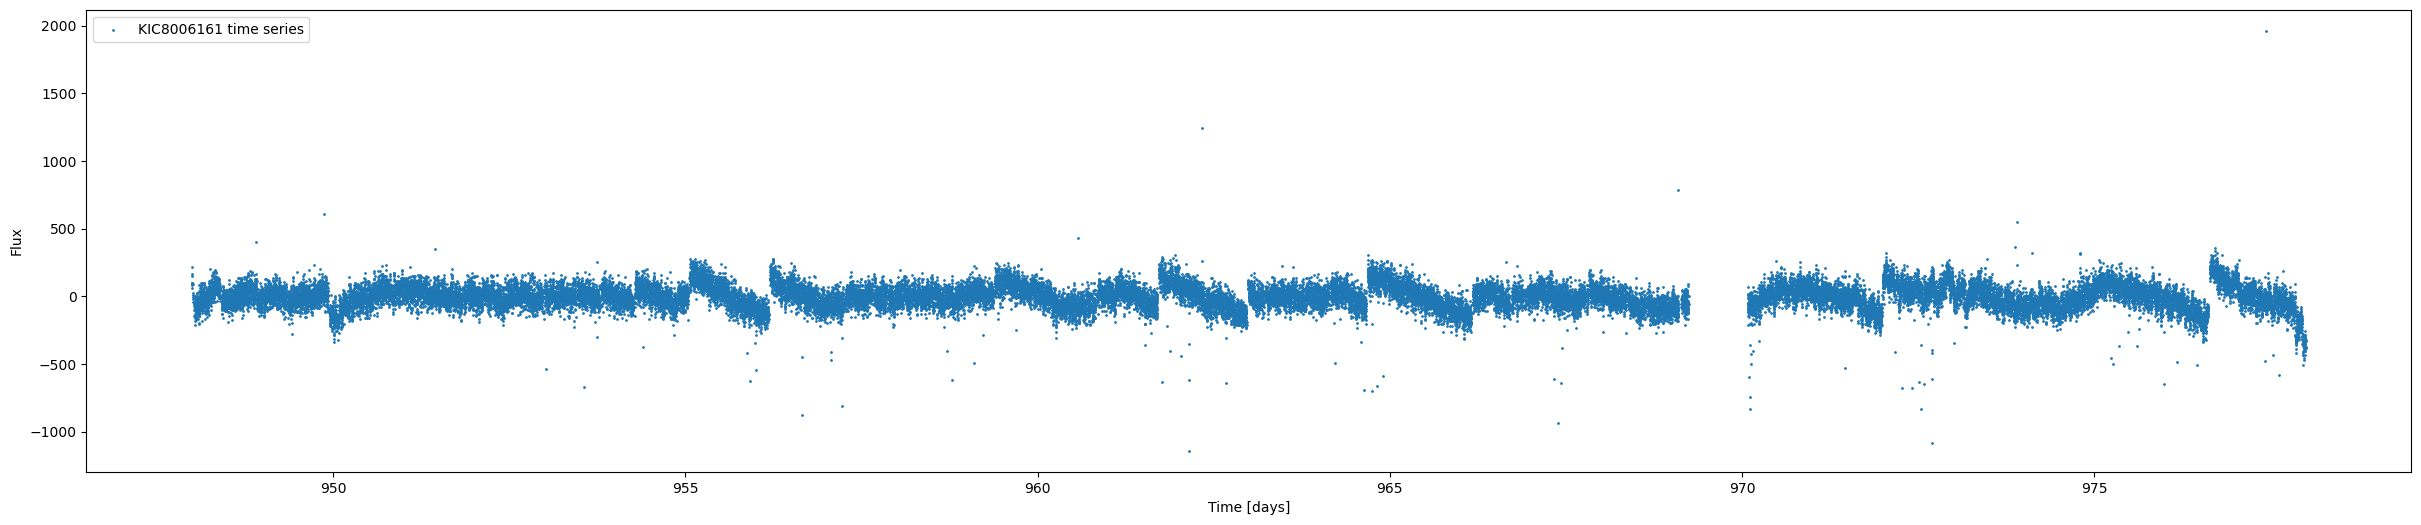

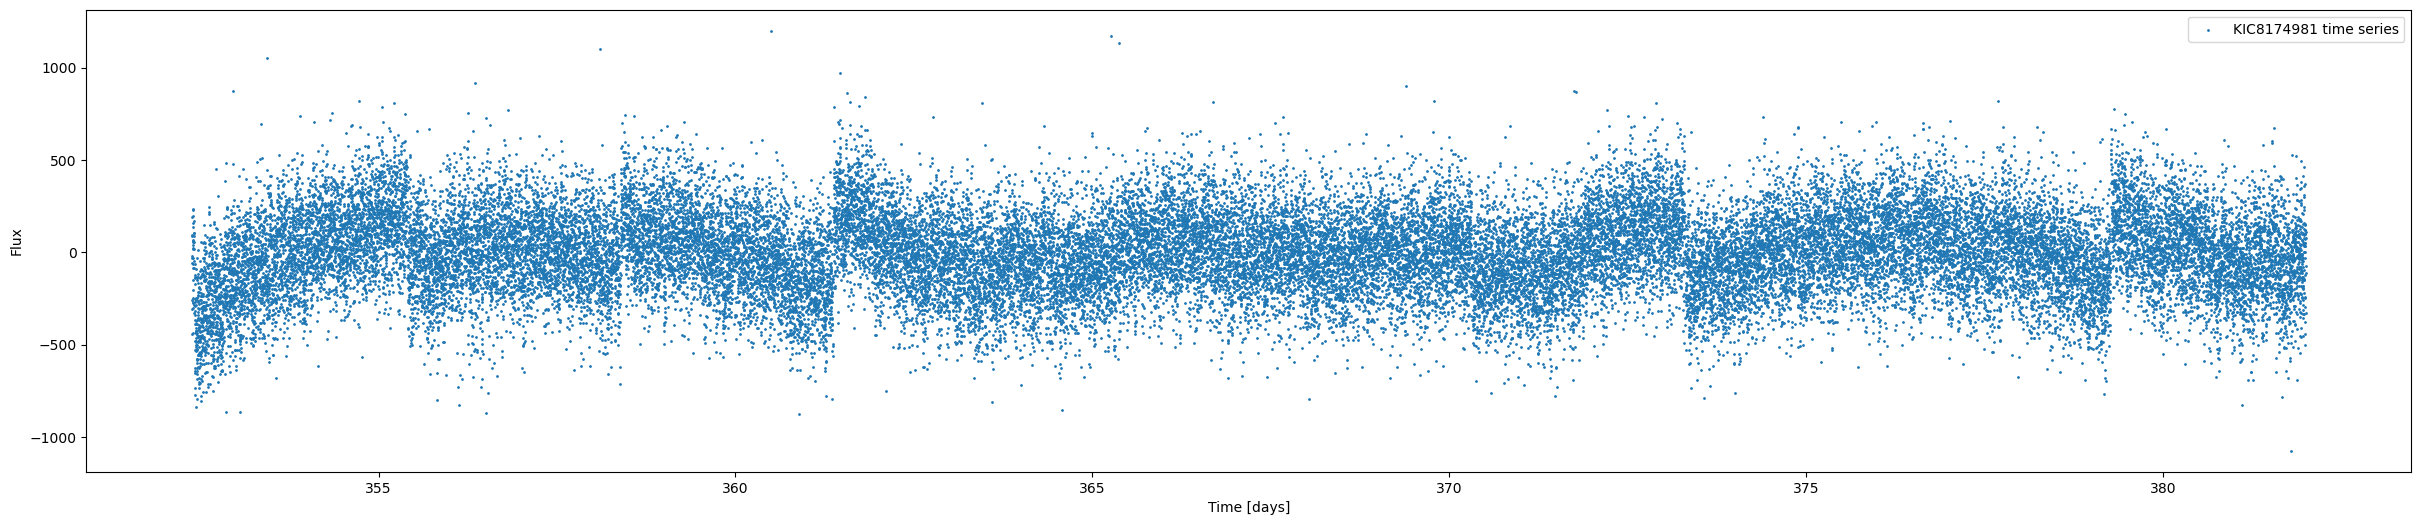

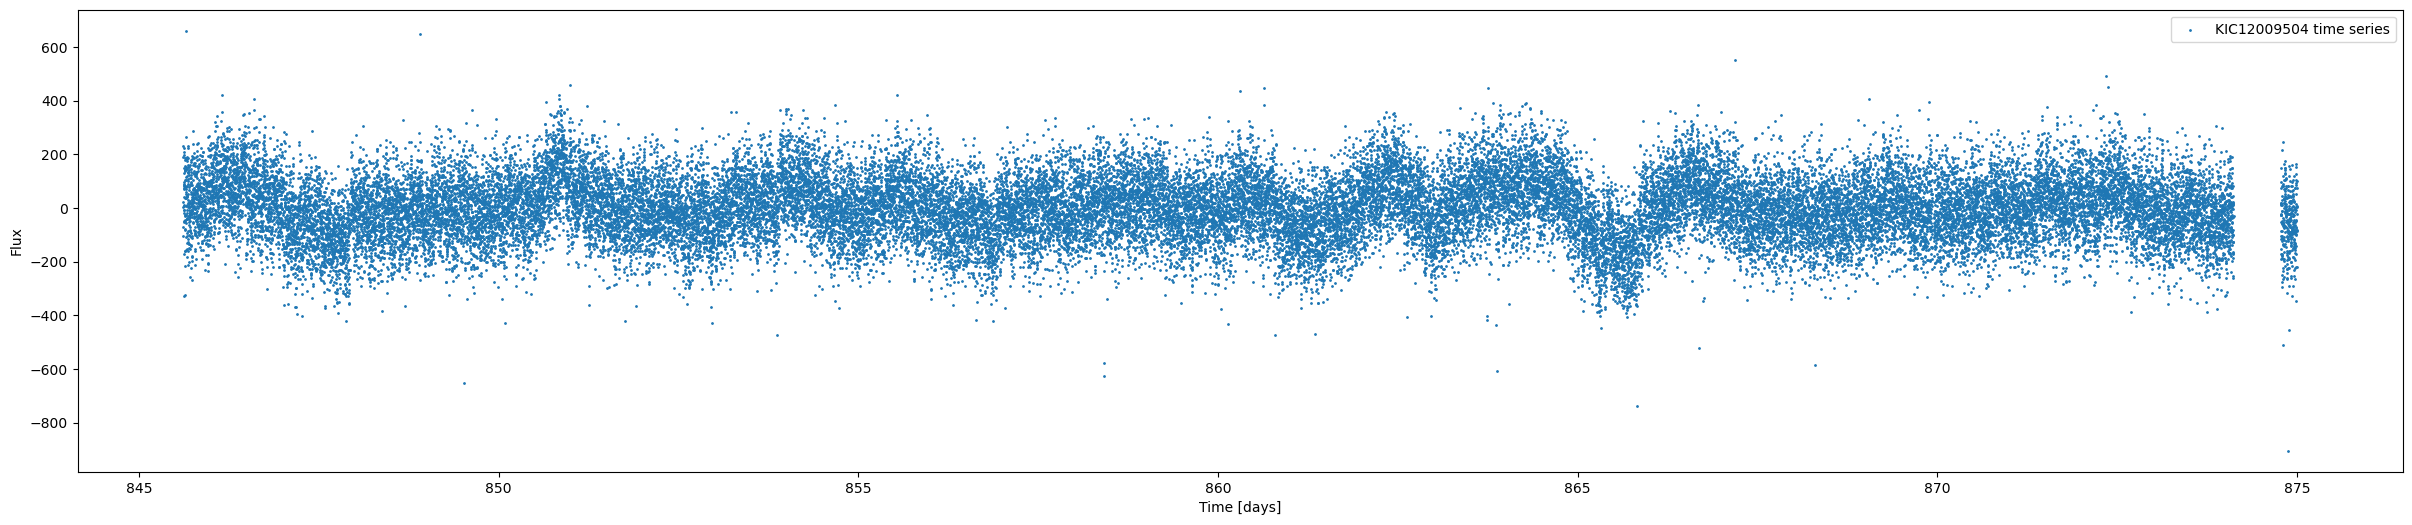

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk

# Define the file paths
file_path1 = r'C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\GroupStudies30dayData\KIC8006161.dat'
file_path2 = r'C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\GroupStudies30dayData\KIC8174981.dat'
file_path3 = r'C:\Users\mason\OneDrive - University of Birmingham\Asteroseismology\Kepler30daypowerspectra\GroupStudies30dayData\KIC12009504.dat'

# Update the files list to use the absolute paths
files = [file_path1, file_path2, file_path3]
time_ranges = [(948, 978), (352, 382), (845, 875)]
labels = ["KIC8006161", "KIC8174981", "KIC12009504"]

times_list = []
fluxes_list = []
lcs_list = []

for f, (t_min, t_max), label in zip(files, time_ranges, labels):
    # Load the data using the full file path
    data = np.loadtxt(f)
    time = data[:, 0]
    flux = data[:, 1]

    # Mask the data based on the specified time ranges
    mask = (time >= t_min) & (time <= t_max)
    time_sel = time[mask]
    flux_sel = flux[mask]

    times_list.append(time_sel)
    fluxes_list.append(flux_sel)

    # Plotting
    fig, ax = plt.subplots(figsize=(30,6))
    lc = lk.LightCurve(time=time_sel, flux=flux_sel)
    lc.scatter(ax=ax, label=f"{label} time series")
    lcs_list.append(lc)
    
    ax.set_xlabel("Time [days]")
    ax.set_ylabel("Flux")
    ax.legend()
    plt.show()

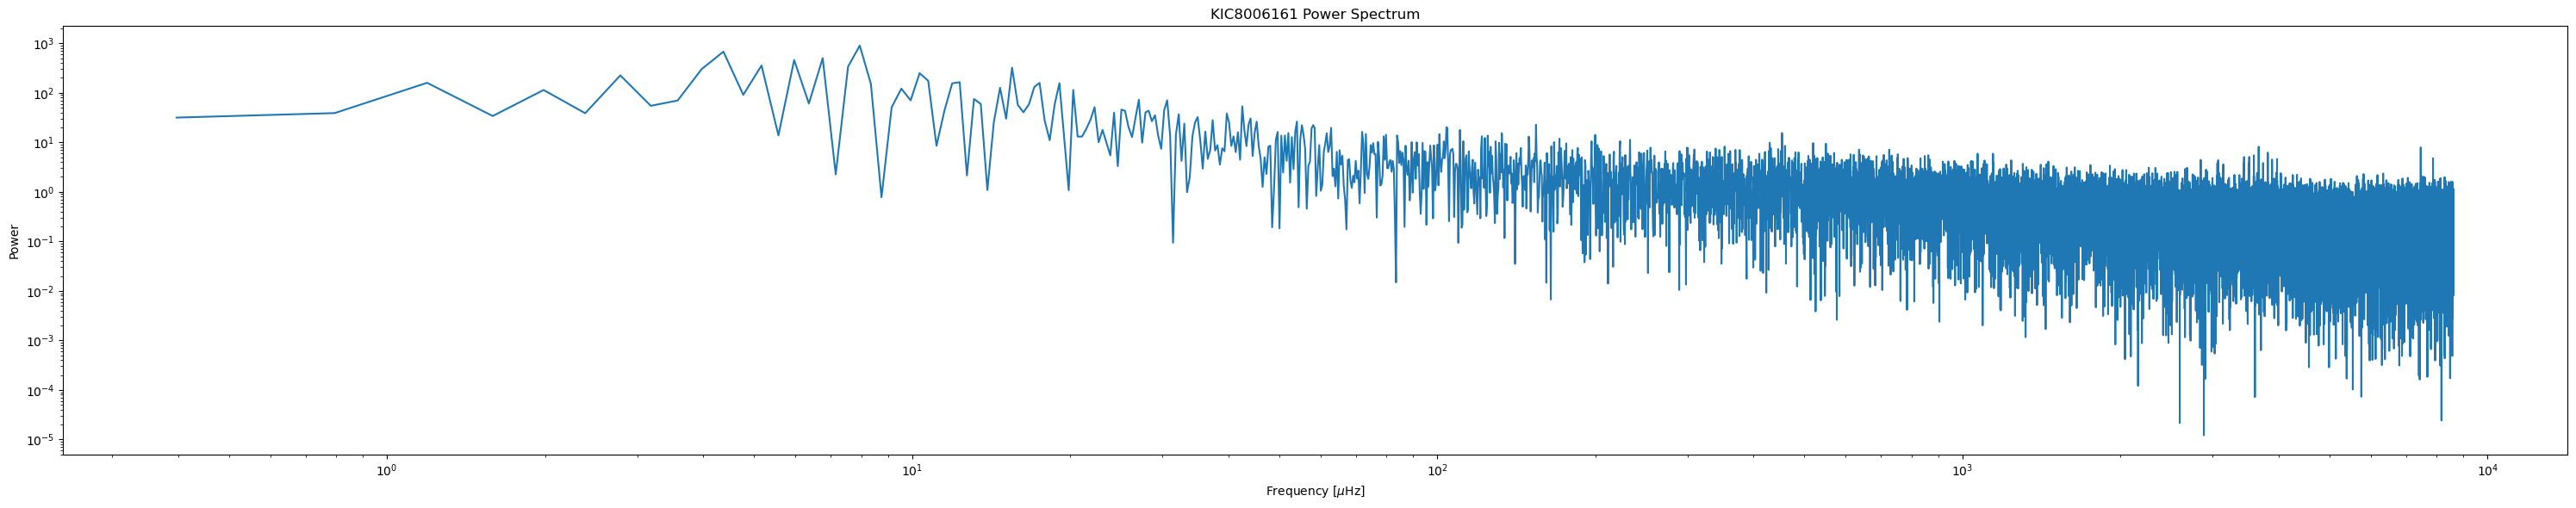

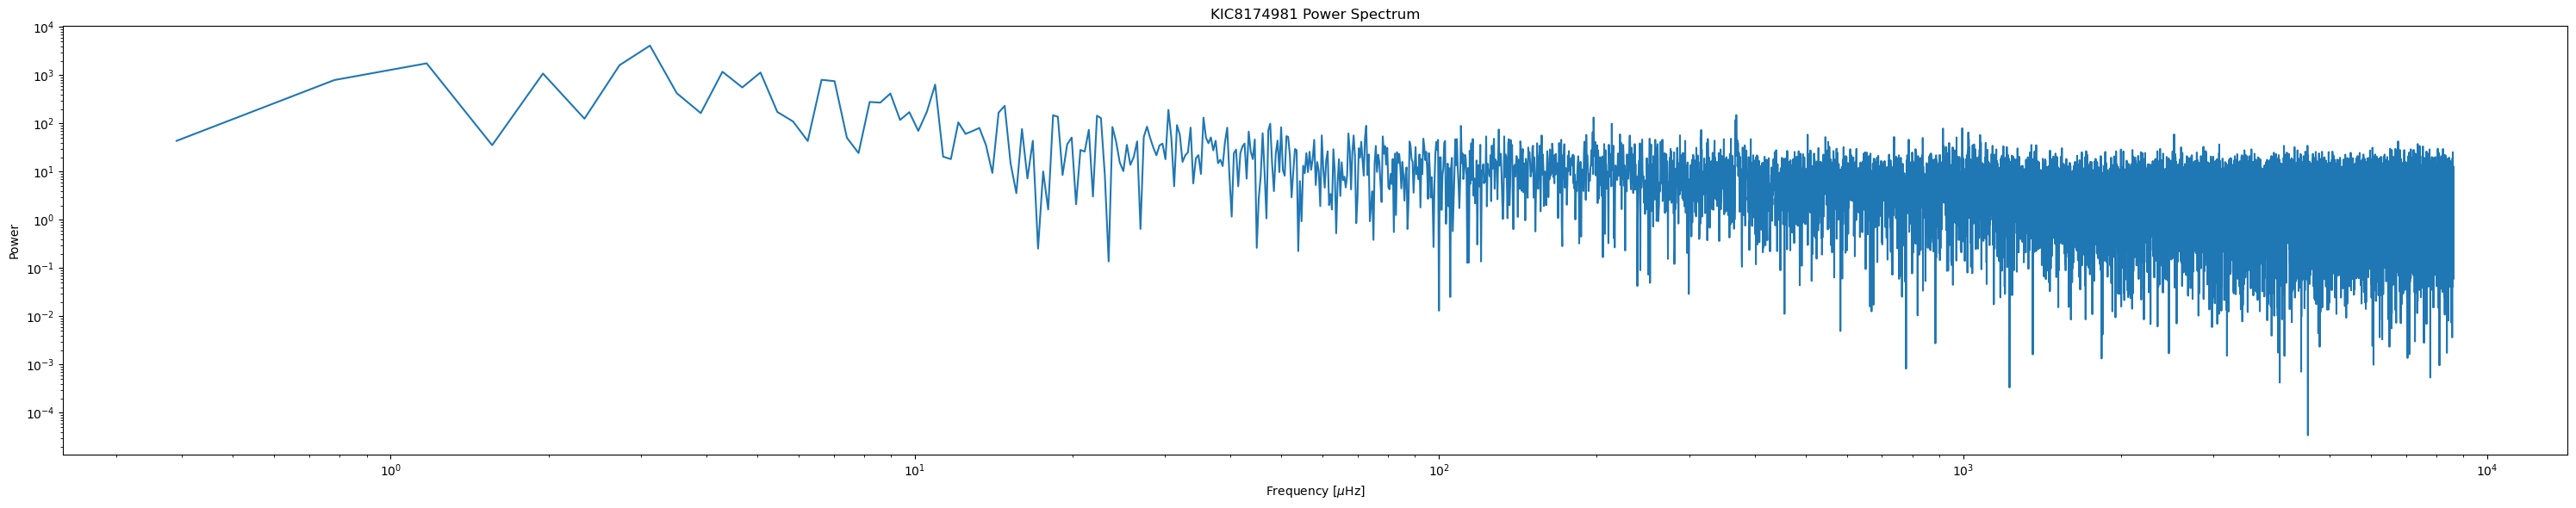

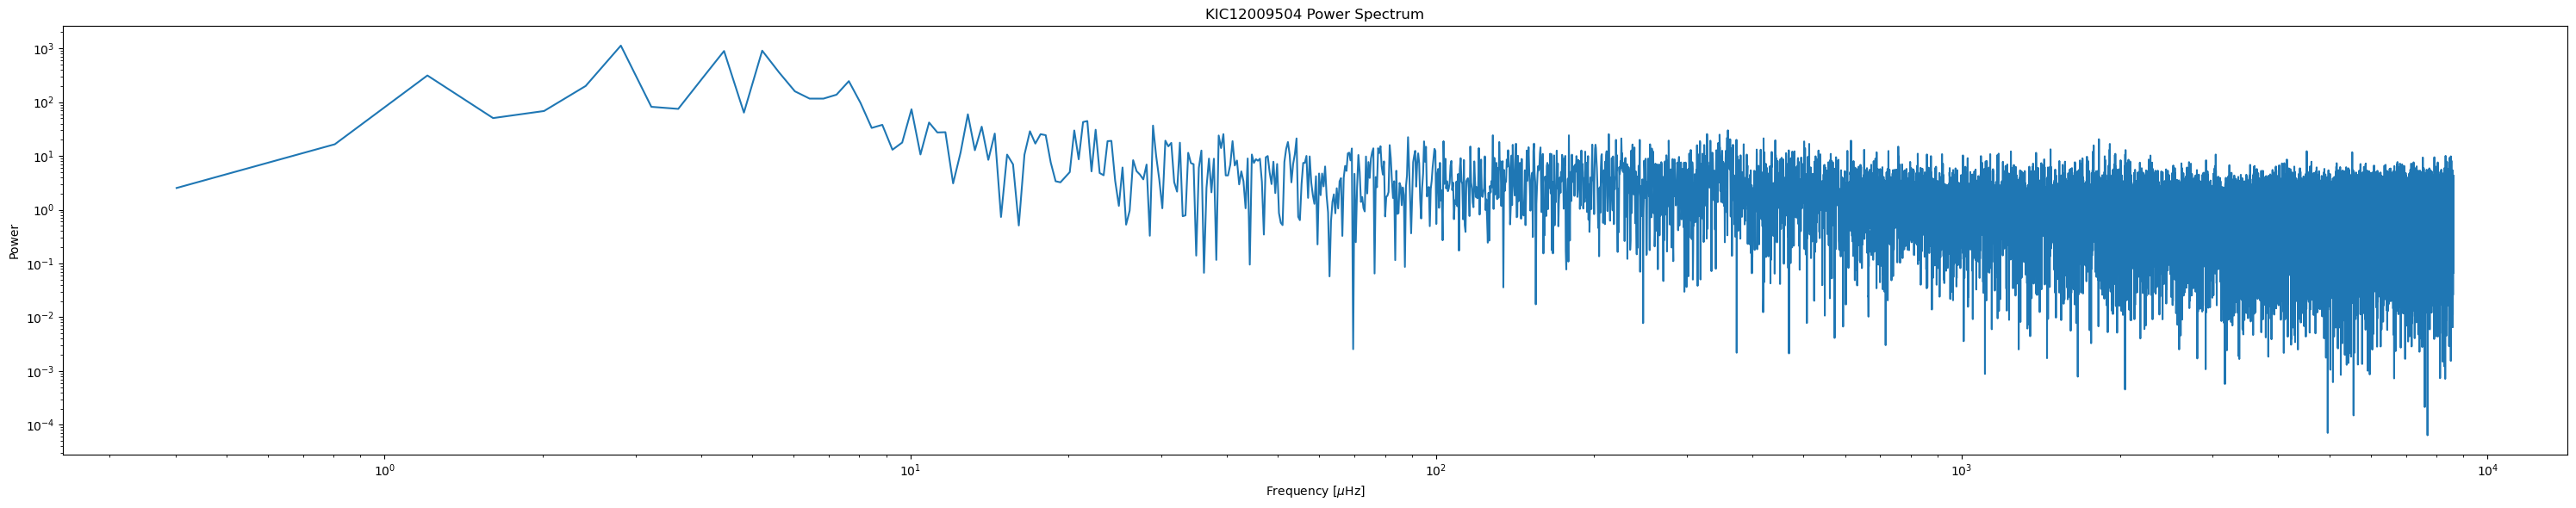

In [16]:
freqs_list = []
powers_list = []

for time_arr, flux_arr, label in zip(times_list, fluxes_list, labels):
    time = np.array(time_arr)
    flux = np.array(flux_arr)

    P = psd(label, time=time, flux=flux)
    P()  # Compute power spectrum

    freq = P.freq  # frequency in μHz
    freqs_list.append(freq)
    power = P.powerdensity  # power density in ppm^2/μHz
    powers_list.append(power)
    
    plt.figure(figsize=(30,6))
    plt.plot(freq, power)
    plt.xlabel("Frequency [$\mu$Hz]")
    plt.ylabel("Power")
    plt.title(f"{label} Power Spectrum")
    plt.yscale("log")
    plt.xscale("log")
    plt.tight_layout()
    plt.show()

In [17]:
# Prepare lists to store results
nu_max_metrics_kepler = []
delta_nu_metrics_kepler = []
combined_metrics_kepler = []

delta_nu_fits = []
delta_nu_errs = []
nu_max_fits = []
nu_max_errs = []

noise_lvls = []
# Loop over all files

# for freq, power, label in tqdm(zip(freqs_list, powers_list, labels)):
#     nu_nyq = np.max(freq)
#     delta_t = (10**6)/(2*nu_nyq)
    
#     nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq)
    
#     nu_max_metrics_kepler.append(nu_max)
#     delta_nu_metrics_kepler.append(delta_nu)
#     combined_metrics_kepler.append(nu_max * delta_nu)

#     delta_nu_fit, delta_nu_err, nu_max_fit, nu_max_err = final_fit(lags_fit, acf_fit, delta_nu_est, acf_power)
    
#     delta_nu_fits.append(delta_nu_fit)
#     delta_nu_errs.append(delta_nu_err)
#     nu_max_fits.append(nu_max_fit)
#     nu_max_errs.append(nu_max_err)

#     noise_lvl = find_noise_lvl(power, freq, nu_max_fit, nu_max_err)

#     noise_lvls.append(noise_lvl)    

# Convert to NumPy arrays for convenience
nu_max_metrics_kepler = np.array(nu_max_metrics_kepler, dtype=float)
delta_nu_metrics_kepler = np.array(delta_nu_metrics_kepler, dtype=float)
combined_metrics_kepler = np.array(combined_metrics_kepler, dtype=float)
delta_nu_fits = np.array(delta_nu_fits)
delta_nu_errs = np.array(delta_nu_errs)
nu_max_fits = np.array(nu_max_fits)
nu_max_errs = np.array(nu_max_errs)
noise_lvls = np.array(noise_lvls)

print("Nu_max metrics:", nu_max_metrics_kepler)
print("Delta_nu metrics:", delta_nu_metrics_kepler)
print("Combined metrics:", combined_metrics_kepler)
print("Delta_nu:", delta_nu_fits)
print("Delta_nu errors:", delta_nu_errs)
print("Nu_max:", nu_max_fits)
print("Nu_max errors:", nu_max_errs)
print("Noise levels:", noise_lvls)

3it [14:02, 280.79s/it]

Nu_max metrics: [4.14453268 3.74634624 4.41865492]
Delta_nu metrics: [5.6068511  2.92792869 3.04386044]
Combined metrics: [23.23777771 10.96903419 13.44976902]
Delta_nu: [144.49502924  52.89614647  88.94267758]
Delta_nu errors: [1.23124008 0.28342761 0.30487165]
Nu_max: [3660.05104697 1021.3188533  1891.18147374]
Nu_max errors: [9.43867433 7.70117622 9.32268001]
Noise levels: [0.28824004 4.15597727 1.05240054]


In [ ]:
import numpy as np

# Pre-calculated asteroseismic parameters to save computation time
nu_max_metrics_kepler = np.array([4.14453268, 3.74634624, 4.41865492])
delta_nu_metrics_kepler = np.array([5.6068511, 2.92792869, 3.04386044])
combined_metrics_kepler = np.array([23.23777771, 10.96903419, 13.44976902])

delta_nu_fits = np.array([144.49502924, 52.89614647, 88.94267758])
delta_nu_errs = np.array([1.23124008, 0.28342761, 0.30487165])

nu_max_fits = np.array([3660.05104697, 1021.3188533, 1891.18147374])
nu_max_errs = np.array([9.43867433, 7.70117622, 9.32268001])

noise_lvls = np.array([0.28824004, 4.15597727, 1.05240054])

In [19]:
delta_t = 10**(6)/(2*np.max(freqs_list[0]))
print(f"Nyquist frequency: {nu_nyq:.2f}")
print(delta_t)

T = 30*24*60*60 #30 days
#N = int(T/(2*delta_t))
N=len(freqs_list[0])
print(f"Number of data points: {N}")

freq_noise=np.linspace(0,nu_nyq,N)
powers_noise=fake_signals(freq_noise,100,noise_lvl)

Nyquist frequency: 8619.36
58.009945
Number of data points: 21683


100%|██████████| 100/100 [00:20<00:00,  4.83it/s]


In [20]:
nu_max_metrics_noise = []
delta_nu_metrics_noise = []
combined_metrics_noise = []
for power in tqdm(powers_noise):
    nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)

    nu_max_metrics_noise.append(nu_max)
    delta_nu_metrics_noise.append(delta_nu)
    combined_metrics_noise.append(nu_max * delta_nu)

nu_max_metrics_noise = np.array(nu_max_metrics_noise)
delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
combined_metrics_noise = np.array(combined_metrics_noise)

100%|██████████| 100/100 [00:46<00:00,  2.15it/s]


In [21]:
def threshold_from_x(x, sig_cad, freq, p):
    nu_nyq = np.max(freq)
    delta_t = 10**(6)/(2*nu_nyq)
    T = 30*24*60*60 #30 days
    N=int(len(freq))
    
    #turn x back into noise_lvl

    sig1hr = (1+x)*sig_cad / np.sqrt(3600/delta_t)
    noise_lvl = (sig1hr**2) * 2 * 3600 * 10**(-6)
    
    freq_noise=np.linspace(0,nu_nyq,N)
    powers_noise=fake_signals(freq_noise,500,noise_lvl)

    nu_max_metrics_noise = []
    #delta_nu_metrics_noise = []
    #combined_metrics_noise = []
    
    for power in tqdm(powers_noise):
        nu_max, delta_nu, lags_fit, acf_fit, delta_nu_est, acf_power = find_metric(power, freq_noise)
    
        nu_max_metrics_noise.append(nu_max)
        #delta_nu_metrics_noise.append(delta_nu)
        #combined_metrics_noise.append(nu_max * delta_nu)
    
    nu_max_metrics_noise = np.array(nu_max_metrics_noise)
    #delta_nu_metrics_noise = np.array(delta_nu_metrics_noise)
    #combined_metrics_noise = np.array(combined_metrics_noise)

    threshold = np.percentile(nu_max_metrics_noise, p)

    return threshold

def make_spectrum_noisy(x, sig_cad, time, flux, label):
    noise = np.random.normal(0,x*sig_cad, size = len(time))
    flux_noisy = flux + noise
    
    P = psd(label, time=time, flux=flux_noisy)
    P()  # Compute power spectrum
    freq_noisy = P.freq  # frequency in μHz
    power_noisy = P.powerdensity  # power density in ppm^2/μHz

    return flux_noisy, freq_noisy, power_noisy

def make_multiple_noisy_spectra(N, x, sig_cad, time, flux, label):
    
    fluxes_noisy = []
    freqs_noisy = []
    powers_noisy = []

    for _ in tqdm(range(N)):
        flux_n, freq_n, power_n = make_spectrum_noisy(x, sig_cad, time, flux, label)
        fluxes_noisy.append(flux_n)
        freqs_noisy.append(freq_n)
        powers_noisy.append(power_n)

    return fluxes_noisy, freqs_noisy, powers_noisy

def detection_probability(x, sig_cad, freq, p, n, time, flux, label):
    threshold = thresholds1[x]
    fluxes_noisy, freqs_noisy, powers_noisy = make_multiple_noisy_spectra(n, x, sig_cad, time, flux, label)

    nu_max_metrics_x = []
    delta_nu_metrics_x = []

    for power, freq_i in tqdm(zip(powers_noisy, freqs_noisy)):
        nu_max_metric, delta_nu_metric, *_  = find_metric(power,freq_i)
        nu_max_metrics_x.append(nu_max_metric)
        delta_nu_metrics_x.append(delta_nu_metric)

    nu_max_metrics_x = np.array(nu_max_metrics_x)

    mean_nu_max_metric = np.mean(nu_max_metrics_x)
    detection_prob = np.sum(nu_max_metrics_x > threshold) / len(nu_max_metrics_x)
        
    return mean_nu_max_metric, detection_prob

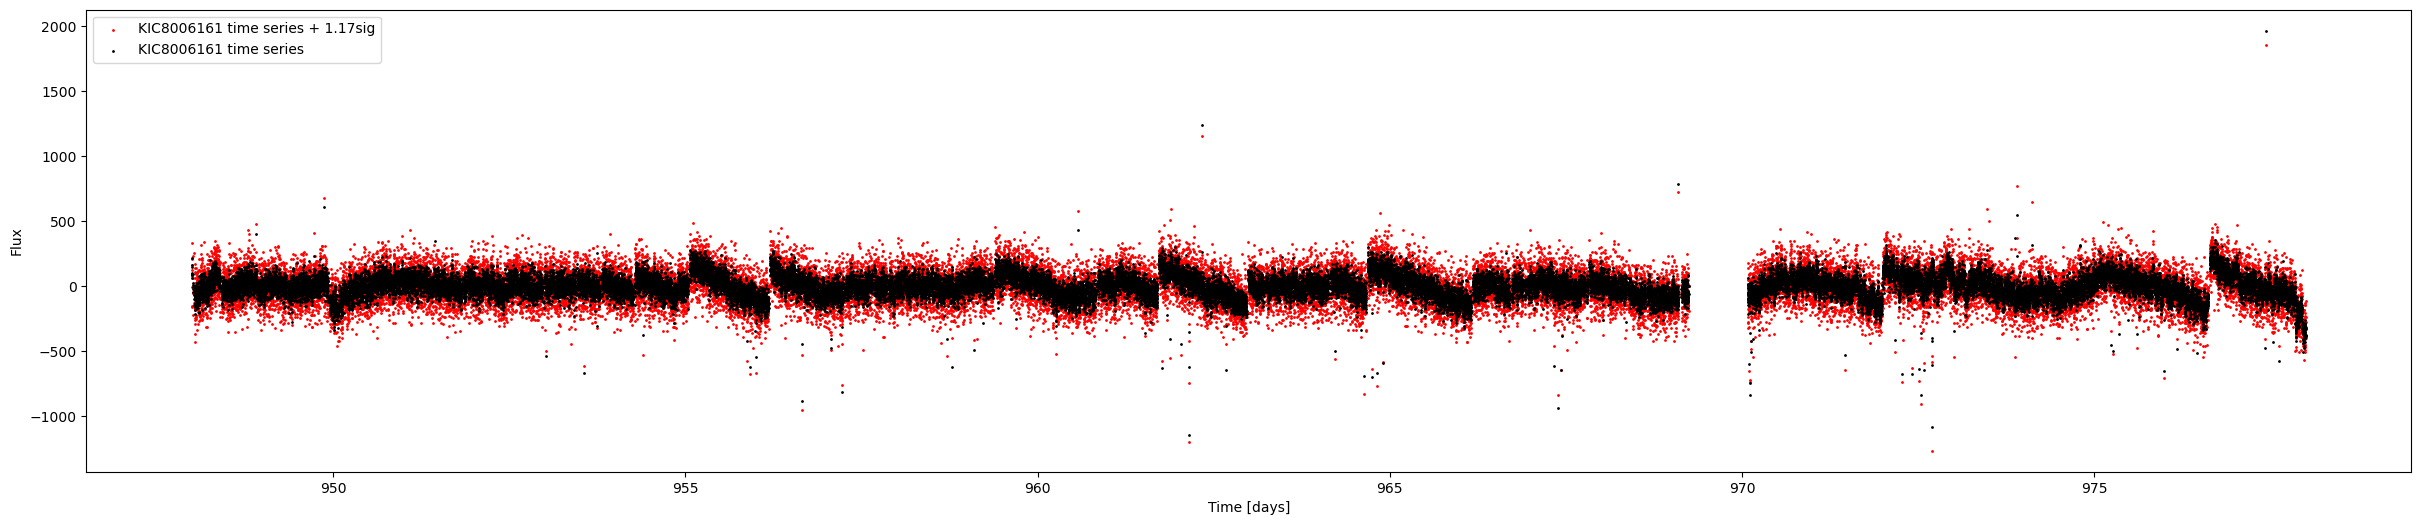

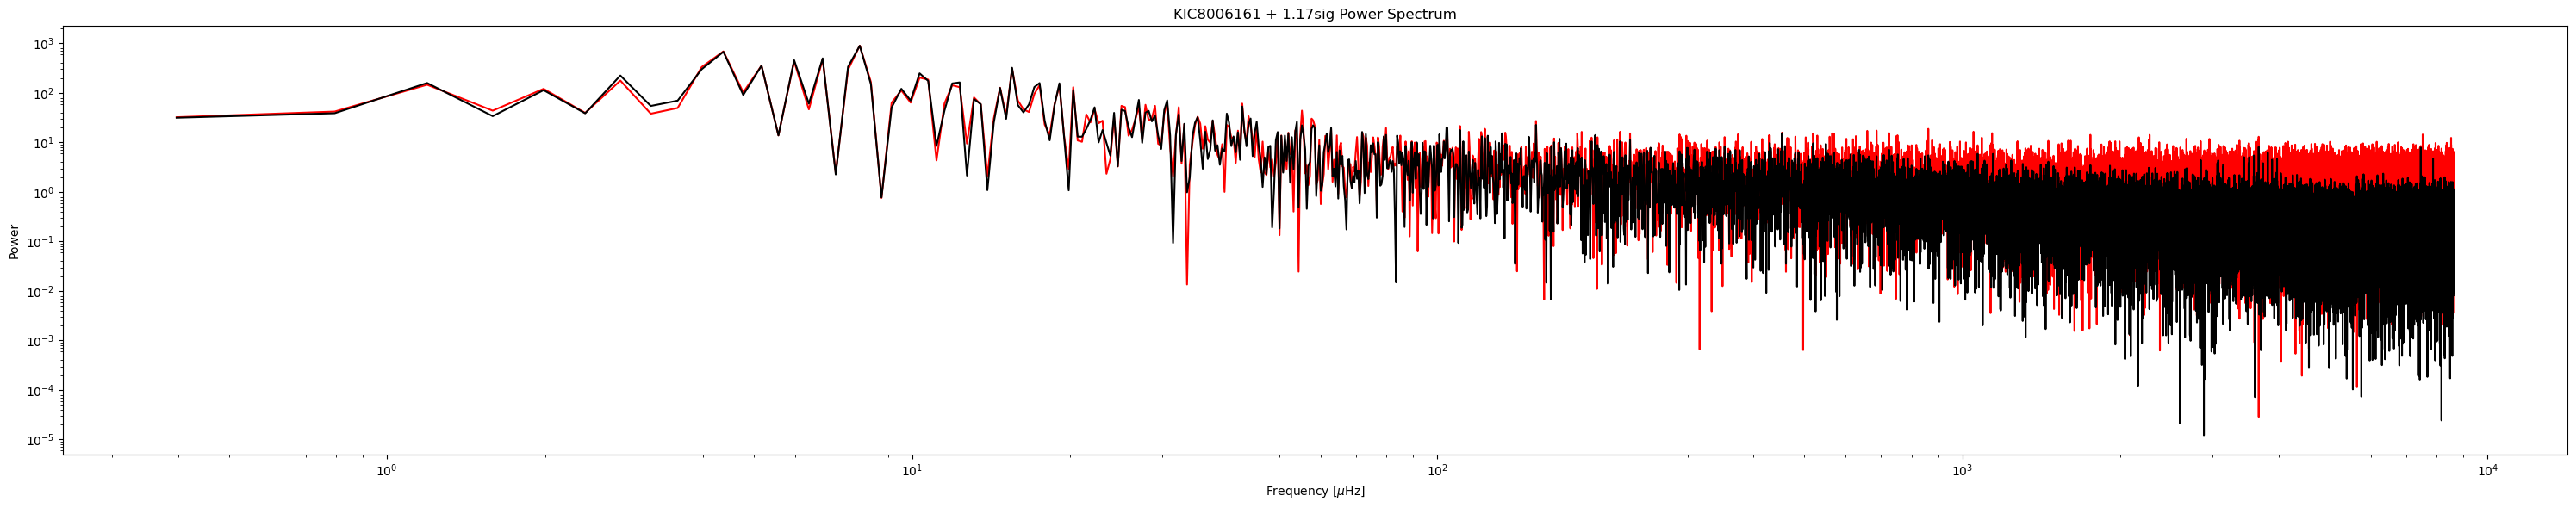

In [24]:
x=1.17

noise_lvls = np.array(noise_lvls)
sig1hrs = (noise_lvls / (2*3600*10**(-6)))**(1/2)
sig_cads = sig1hrs * np.sqrt(3600/delta_t)

flux_noisy1, freq_noisy1, power_noisy1 = make_spectrum_noisy(2, sig_cads[0], times_list[0], fluxes_list[0], labels[0])

fig, ax = plt.subplots(figsize=(30,6))
lc_noise = lk.LightCurve(time=times_list[0], flux=flux_noisy1)
lc_noise.scatter(ax=ax, label=f"{labels[0]} time series + {x}sig", c = "r")
lcs_list[0].scatter(ax=ax, label = f"{labels[0]} time series", c = "k")
ax.set_xlabel("Time [days]")
ax.set_ylabel("Flux")
ax.legend()
plt.show()
    
plt.figure(figsize=(30,6))
plt.plot(freq_noisy1, power_noisy1, c = "r")
plt.plot(freqs_list[0], powers_list[0], c= "k")
plt.xlabel("Frequency [$\mu$Hz]")
plt.ylabel("Power")
plt.title(f"{labels[0]} + {x}sig Power Spectrum")
plt.yscale("log")
plt.xscale("log")
plt.tight_layout()
plt.show()

In [25]:
x_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.2]
thresholds1 = {
    x: threshold_from_x(x, sig_cads[0], freqs_list[0], 99)
    for x in x_values
}

100%|██████████| 500/500 [04:00<00:00,  2.08it/s]


In [26]:
#REDEFINE SLIDING AUTOCORRELATION FOR RUN_FULL_PIPELINE
    
def sliding_acf_search(frequency, power_flat, numax_grid,
                       k_width=5.0,
                       lag_frac=(0.8, 1.2)):

    acf_strength = []
    acf_strength_notSNR = []

    df = frequency[1] - frequency[0]

    for nu_c in numax_grid:

        dnu = delta_nu_from_numax(nu_c)
        W = k_width * dnu

        mask = (frequency > nu_c - W/2) & (frequency < nu_c + W/2)

        if mask.sum() < 20:
            acf_strength.append(0.0)
            acf_strength_notSNR.append(0.0)
            continue

        p = power_flat[mask]
        p = p / np.median(p)

        acf = np.correlate(p - np.mean(p), p - np.mean(p), mode="full")
        acf = acf[acf.size // 2:]

        lag = np.arange(acf.size) * df
        lag_mask = (lag > lag_frac[0]*dnu) & (lag < lag_frac[1]*dnu)

        signal = np.max(acf[lag_mask])
        noise = np.median(acf[~lag_mask])
        sigma = np.std(acf[~lag_mask])

        SNR = (signal - noise) / sigma

        acf_strength.append(SNR)
        acf_strength_notSNR.append(signal)

    return np.array(acf_strength), np.array(acf_strength_notSNR)


Evaluating pipeline robustness for KIC8006161...

--- Testing noise level x = 0.0 ---


100%|██████████| 500/500 [00:54<00:00,  9.14it/s]


Detection probability for x=0.0: 100.0% (500/500)

--- Testing noise level x = 0.2 ---


100%|██████████| 500/500 [00:58<00:00,  8.61it/s]


Detection probability for x=0.2: 87.0% (435/500)

--- Testing noise level x = 0.4 ---


...

Detection probability for x=0.8: 72.2% (361/500)

--- Testing noise level x = 1 ---


100%|██████████| 500/500 [00:58<00:00,  8.60it/s]


Detection probability for x=1: 34.6% (173/500)

--- Testing noise level x = 1.2 ---


100%|██████████| 500/500 [00:57<00:00,  8.66it/s]


Detection probability for x=1.2: 8.4% (42/500)


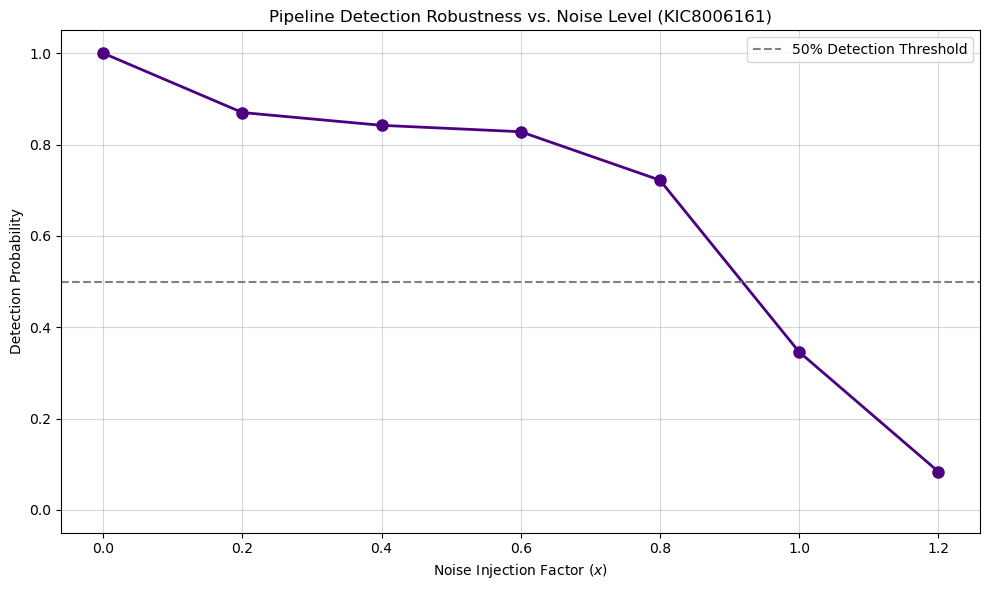

In [28]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define how many synthetic spectra to test per noise level
N_trials = 500 

detection_probabilities = []

print(f"Evaluating pipeline robustness for {labels[0]}...")

for x in x_values:
    print(f"\n--- Testing noise level x = {x} ---")
    
    # 1. Generate the noisy spectra using your previously defined function
    fluxes_noisy, freqs_noisy, powers_noisy = make_multiple_noisy_spectra(
        N=N_trials, 
        x=x, 
        sig_cad=sig_cads[0], 
        time=times_list[0], 
        flux=fluxes_list[0], 
        label=labels[0]
    )
    
    successful_detections = 0
    
    # 2. Run your Mark IV pipeline on each noisy spectrum
    for freq_n, power_n in zip(freqs_noisy, powers_noisy):
        # We catch the boolean 'detected' flag your pipeline returns
        detected, diagnostics = run_full_pipeline(freq_n, power_n, return_diagnostics=True)
        
        if detected:
            successful_detections += 1
            
    # 3. Calculate and store the probability
    prob = successful_detections / N_trials
    detection_probabilities.append(prob)
    print(f"Detection probability for x={x}: {prob*100:.1f}% ({successful_detections}/{N_trials})")

# ==========================================
# Plotting the Pipeline Sensitivity Curve
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(x_values, detection_probabilities, marker='o', markersize=8, linestyle='-', color='indigo', linewidth=2)

plt.axhline(0.5, color='gray', linestyle='--', label="50% Detection Threshold")

plt.xlabel("Noise Injection Factor ($x$)")
plt.ylabel("Detection Probability")
plt.title(f"Pipeline Detection Robustness vs. Noise Level ({labels[0]})")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Evaluating pipeline robustness for KIC8006161...

--- Testing noise level x = 0.0 ---


100%|██████████| 50/50 [00:05<00:00,  9.83it/s]


Detection probability for x=0.0: 100.0% (50/50)

--- Testing noise level x = 0.2 ---


100%|██████████| 50/50 [00:05<00:00, 10.00it/s]


Detection probability for x=0.2: 90.0% (45/50)

--- Testing noise level x = 0.4 ---


...

Detection probability for x=0.8: 72.0% (36/50)

--- Testing noise level x = 1 ---


100%|██████████| 50/50 [00:05<00:00,  9.27it/s]


Detection probability for x=1: 32.0% (16/50)

--- Testing noise level x = 1.2 ---


100%|██████████| 50/50 [00:05<00:00,  9.67it/s]


Detection probability for x=1.2: 4.0% (2/50)


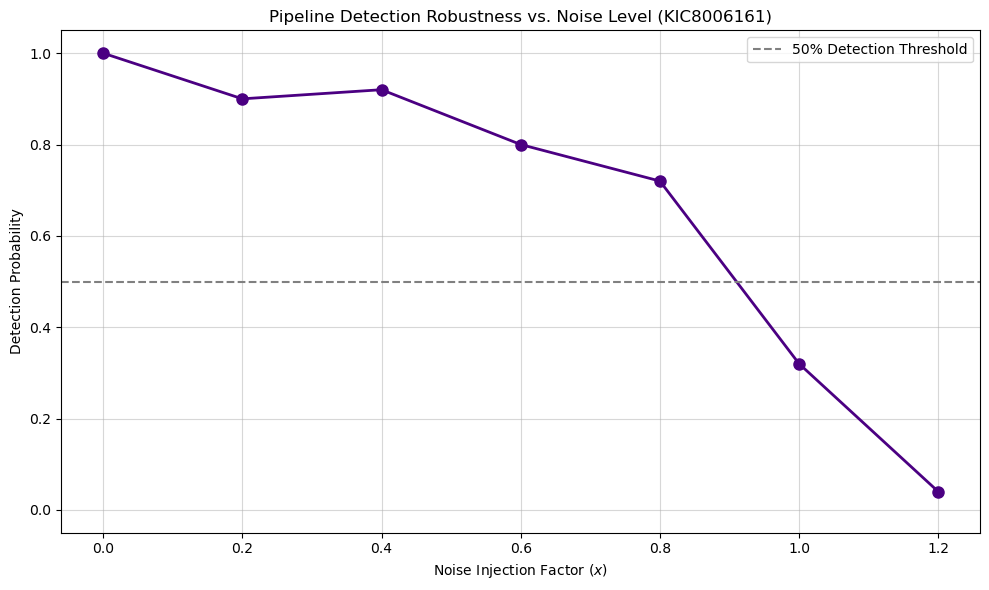

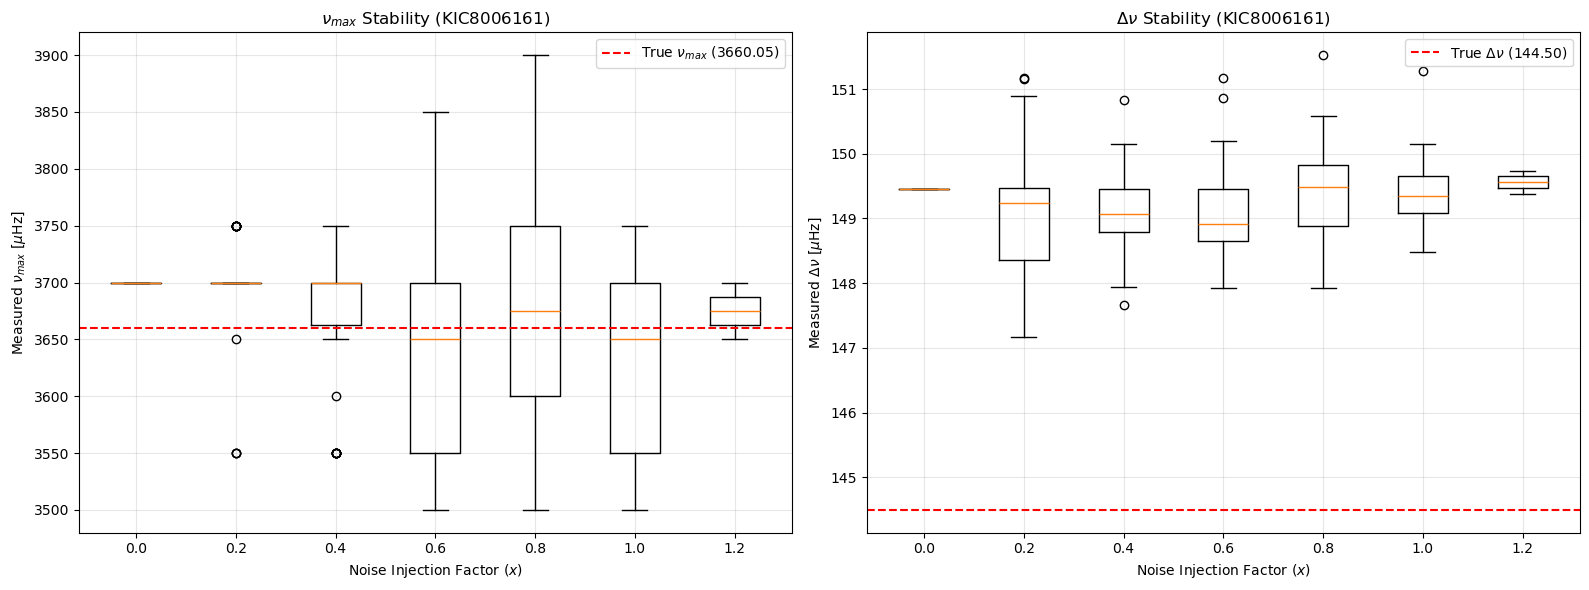

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Define how many synthetic spectra to test per noise level
N_trials = 50 

STAR_IDX = 0

detection_probabilities = []

# --- NEW: Dictionaries to track measurements ---
tracked_numax = {x: [] for x in x_values}
tracked_deltanu = {x: [] for x in x_values}

print(f"Evaluating pipeline robustness for {labels[STAR_IDX]}...")

for x in x_values:
    print(f"\n--- Testing noise level x = {x} ---")
    
    # 1. Generate the noisy spectra
    fluxes_noisy, freqs_noisy, powers_noisy = make_multiple_noisy_spectra(
        N=N_trials, 
        x=x, 
        sig_cad=sig_cads[STAR_IDX], 
        time=times_list[STAR_IDX], 
        flux=fluxes_list[STAR_IDX], 
        label=labels[STAR_IDX]
    )
    
    successful_detections = 0
    
    # 2. Run your Mark IV pipeline on each noisy spectrum
    for freq_n, power_n in zip(freqs_noisy, powers_noisy):
        # We catch the boolean 'detected' flag your pipeline returns
        detected, diagnostics = run_full_pipeline(freq_n, power_n, return_diagnostics=True)
        
        if detected:
            successful_detections += 1
            # --- NEW: Save the measurements for this detection ---
            tracked_numax[x].append(diagnostics['numax_est'])
            tracked_deltanu[x].append(diagnostics['dnu_final'])
            
    # 3. Calculate and store the probability
    prob = successful_detections / N_trials
    detection_probabilities.append(prob)
    print(f"Detection probability for x={x}: {prob*100:.1f}% ({successful_detections}/{N_trials})")

# ==========================================
# Plot 1: The Pipeline Sensitivity Curve
# ==========================================
plt.figure(figsize=(10, 6))
plt.plot(x_values, detection_probabilities, marker='o', markersize=8, linestyle='-', color='indigo', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', label="50% Detection Threshold")
plt.xlabel("Noise Injection Factor ($x$)")
plt.ylabel("Detection Probability")
plt.title(f"Pipeline Detection Robustness vs. Noise Level ({labels[STAR_IDX]})")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# Plot 2: Parameter Stability Over Noise
# ==========================================
# Extract the true values for this specific star
true_numax = nu_max_fits[STAR_IDX]
true_deltanu = delta_nu_fits[STAR_IDX]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for boxplots
numax_data = [tracked_numax[x] for x in x_values]
deltanu_data = [tracked_deltanu[x] for x in x_values]

# Plot numax distributions
ax1.boxplot(numax_data, positions=x_values, widths=0.1, manage_ticks=False)
ax1.axhline(true_numax, color='red', linestyle='--', label=f'True $\\nu_{{max}}$ ({true_numax:.2f})')
ax1.set_xlabel("Noise Injection Factor ($x$)")
ax1.set_ylabel("Measured $\\nu_{{max}}$ [$\\mu$Hz]")
ax1.set_title(f"$\\nu_{{max}}$ Stability ({labels[STAR_IDX]})")
ax1.grid(alpha=0.3)
ax1.legend()

# Plot delta nu distributions
ax2.boxplot(deltanu_data, positions=x_values, widths=0.1, manage_ticks=False)
ax2.axhline(true_deltanu, color='red', linestyle='--', label=f'True $\\Delta\\nu$ ({true_deltanu:.2f})')
ax2.set_xlabel("Noise Injection Factor ($x$)")
ax2.set_ylabel("Measured $\\Delta\\nu$ [$\\mu$Hz]")
ax2.set_title(f"$\\Delta\\nu$ Stability ({labels[STAR_IDX]})")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
ps = psd(ID=None, time=t_30, flux=flux_30)
ps()

freq_new = np.array(ps.freq)
power_new = np.array(ps.powerdensity)

freq_data = np.loadtxt(real_files[2])
freq_old = freq_data[:, 0]
power_old = freq_data[:, 1]

In [ ]:
plt.figure()
plt.plot(freq_old, power_old, alpha=0.6, label="Old")
plt.plot(freq_new, power_new, alpha=0.6, label="New")
plt.yscale("log")  # standard for asteroseismic power spectra
plt.xscale("log")
plt.legend()
print("Old df:", freq_old[1] - freq_old[0])
print("New df:", freq_new[1] - freq_new[0])

print("Old max freq:", freq_old.max())
print("New max freq:", freq_new.max())

print("Old mean power:", np.mean(power_old))
print("New mean power:", np.mean(power_new))

In [ ]:

# Create a results list for the real stars
real_results = []

# --- Run Fake Signals (Controlled Grid) ---
for i in tqdm(range(len(fake)), desc="Checking False Alarms"):
    detected, diag = run_full_pipeline(freq, fake[i], return_diagnostics=True)
    if detected:
        false_cases.append(diag)

# --- Run Real Signals (Native Grids) ---
print("\n--- Processing Real Stars ---")
for f_native, p_native, name in real_data_list:
    # We pass the NATIVE frequency array for each specific star
    detected, diag = run_full_pipeline(f_native, p_native, return_diagnostics=True)
    
    result_str = "ACCEPTED" if detected else f"REJECTED ({diag['status']})"
    print(f"{name}: {result_str}")
    
    # Store diagnostics for plotting later
    real_results.append((name, detected, diag))

# --- Sanity Check: Recomputed PSD from Lightcurve ---
print("\n--- Sanity Check: Recomputed PSD (30-day masked) ---")

detected_new, diag_new = run_full_pipeline(freq_new, power_new, return_diagnostics=True)

result_str_new = "ACCEPTED" if detected_new else f"REJECTED ({diag_new['status']})"
print(f"Recomputed PSD: {result_str_new}")

# Optional: store separately if you want to inspect later
recomputed_result = (detected_new, diag_new)
print(f"Numax (new PSD): {diag_new.get('numax_est', 'N/A')}")

false_detections = len(false_cases)
print(f"\nFalse detections: {false_detections} / {len(fake)}")
print(f"False alarm rate: {false_detections / len(fake):.3f}")

In [ ]:
# # --- Inspect original accepted star ---
# for name, detected, diag in real_results:
#     inspect_numax_uniqueness(diag, title=f"{name} — νmax Uniqueness")

# # --- Inspect recomputed PSD ---
# inspect_numax_uniqueness(diag_new, title="Recomputed PSD — νmax Uniqueness")


In [ ]:
# for name, detected, diag in real_results:
#     inspect_dnu_stage(diag, "OLD Δν Stage")
# inspect_dnu_stage(diag_new, "NEW Δν Stage")


In [ ]:
print("\n--- Detailed Comparison ---")

detected_old, diag_old = run_full_pipeline(freq_old, power_old, return_diagnostics=True)

print("Old numax:", diag_old.get("numax_est"))
print("New numax:", diag_new.get("numax_est"))

print("Old SNR:", diag_old.get("snr"))
print("New SNR:", diag_new.get("snr"))

print("Old status:", diag_old.get("status"))
print("New status:", diag_new.get("status"))


In [ ]:
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
import numpy as np

# --- Define grid exactly as in pipeline ---
numax_grid = np.linspace(50, 5000, 100)

# --- Prepare flattened spectra (same as pipeline Phase 1) ---
def prepare_flat(freq, power):
    df = freq[1] - freq[0]
    smooth_width_bins = int(600 / df)
    background = uniform_filter1d(power, size=smooth_width_bins)
    return power / background

power_flat_old = prepare_flat(freq_old, power_old)
power_flat_new = prepare_flat(freq_new, power_new)

# --- Run sliding ACF search (ignore SNR output) ---
_, acf_raw_old = sliding_acf_search(freq_old, power_flat_old, numax_grid)
_, acf_raw_new = sliding_acf_search(freq_new, power_flat_new, numax_grid)

# --- Smooth RAW curves (same smoothing as pipeline) ---
smooth_size = 7
acf_raw_old_s = uniform_filter1d(acf_raw_old, size=smooth_size)
acf_raw_new_s = uniform_filter1d(acf_raw_new, size=smooth_size)

# --- Find νmax from smoothed RAW ---
imax_old = np.argmax(acf_raw_old_s)
imax_new = np.argmax(acf_raw_new_s)

numax_old = numax_grid[imax_old]
numax_new = numax_grid[imax_new]

# --- Exclusion zone (must match pipeline) ---
exclude = 4  # same as pipeline

def exclusion_bounds(imax):
    start = max(0, imax - exclude)
    end = min(len(numax_grid) - 1, imax + exclude)
    return numax_grid[start], numax_grid[end]

old_lo, old_hi = exclusion_bounds(imax_old)
new_lo, new_hi = exclusion_bounds(imax_new)

# ============================================================
# Plot OLD
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(numax_grid, acf_raw_old, alpha=0.4, label="Raw ACF")
plt.plot(numax_grid, acf_raw_old_s, linewidth=2, label="Smoothed Raw ACF")

plt.axvline(numax_old, linestyle='--', label=f"Selected νmax = {numax_old:.1f}")

plt.axvspan(old_lo, old_hi, alpha=0.15, label="Exclusion zone")

plt.xlabel("νmax (μHz)")
plt.ylabel("Raw ACF peak")
plt.title("OLD PSD — Sliding Raw ACF")
plt.legend()
plt.show()


# ============================================================
# Plot NEW
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(numax_grid, acf_raw_new, alpha=0.4, label="Raw ACF")
plt.plot(numax_grid, acf_raw_new_s, linewidth=2, label="Smoothed Raw ACF")

plt.axvline(numax_new, linestyle='--', label=f"Selected νmax = {numax_new:.1f}")

plt.axvspan(new_lo, new_hi, alpha=0.15, label="Exclusion zone")

plt.xlabel("νmax (μHz)")
plt.ylabel("Raw ACF peak")
plt.title("NEW PSD — Sliding Raw ACF")
plt.legend()
plt.show()


In [ ]:
# --- DIAGNOSTIC PLOTTING FOR STAR 3 (KIC12009504) ---
staridx = 0
# Find the diagnostic dictionary for Star 3
# Index 2 corresponds to the 3rd star in your real_files list
star_name, detected, case = real_results[staridx]

print(f"Analyzing {star_name}...")
print(f"Status: {case['status']}")
print(f"Contrast: {case['peak_contrast']:.2f} (Threshold: 2.0)")
print(f"Ratio: {case['peak_ratio']:.2f} (Threshold: 1.2)")
# Assuming 'case' is your dictionary:
print(f"Δν = {case['dnu_final']:.3f} ± {case['popt'][2]/case['peak_contrast']:.3f} μHz") if case['dnu_final'] else print("No detection.")


# --- PLOT 1: NuMax Search Logic ---
plt.figure(figsize=(10, 7))

# Top: SNR of the sliding ACF
plt.subplot(2, 1, 1)
plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3, label="SNR Curve")
plt.scatter(case["numax_grid"][case["valid"]], case["acf_snr"][case["valid"]], color="C0", s=20, label="Valid")
plt.axhline(3, ls="--", color="red", label="Threshold (3σ)")
plt.ylabel("ACF SNR")
plt.title(f"NuMax Detection Analysis: {star_name} (νmax Est: {case['numax_est']:.1f} μHz)")
plt.legend()

# Bottom: Raw ACF strength
plt.subplot(2, 1, 2)
plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], color="C3", s=100, zorder=5, label="Primary Peak")

# Highlight the exclusion zone around the primary peak
exc = case["exclude"]
idx = case["imax"]
plt.axvspan(case["numax_grid"][max(0, idx-exc)], 
            case["numax_grid"][min(len(case["numax_grid"])-1, idx+exc)], 
            color="C3", alpha=0.1, label="Exclusion Zone")

plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
plt.ylabel("Raw ACF Strength")
plt.legend()
plt.tight_layout()
plt.show()

# --- PLOT 2: Dnu Search & Gaussian Fit ---
plt.figure(figsize=(8, 4))
plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k", label="ACF Data", zorder=2)
plt.axhline(case["noise_level"], color="grey", ls="--", label="Noise Level")

# 1. Show the Gaussian Fit
if case["popt"] is not None and any(case["popt"]):
    lags_smooth = np.linspace(case["lags_fit"].min(), case["lags_fit"].max(), 500)
    fit_curve = gaussian(lags_smooth, *case["popt"])
    plt.plot(lags_smooth, fit_curve, color="C1", lw=2, label="Gaussian Model", zorder=3)

# 2. Highlight the ADAPTIVE Exclusion Zone
exc = case["exclude_dnu"]
idx = case["imax_dnu"]
lags_fit = case["lags_fit"]

# Calculate the actual lag values for the shading
low_bound = lags_fit[max(0, idx - exc)]
high_bound = lags_fit[min(len(lags_fit) - 1, idx + exc)]

plt.axvspan(low_bound, high_bound, color="C1", alpha=0.15, label=f"Adaptive Exclusion ({exc} bins)")

# 3. Mark the final detection
if case["dnu_final"] is not None:
    plt.axvline(case["dnu_final"], color="r", ls="--", label=rf"Final $\Delta\nu$ = {case['dnu_final']:.2f}")

plt.title(rf"$\Delta\nu$ Validation: {star_name} ({case['status']})")
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalized ACF")
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()

# --- PLOT 3: Significance/Contrast ---
plt.figure(figsize=(8, 4))
plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k")
nl, ns = case["noise_level"], case["noise_sigma"]
plt.axhline(nl, color="grey", ls="--")
plt.axhline(nl + ns, ls=":", color="C0", label="+1σ")
plt.axhline(nl + 2*ns, ls=":", color="C1", label="+2σ")
plt.plot(case["lags_fit"][np.argmax(case["acf_fit"])], case["peak_main"], "ro")

plt.title(rf"ACF Peak Contrast = {case['peak_contrast']:.2f}")
plt.xlabel(r"Lag [$\mu$Hz]")
plt.ylabel("Normalized ACF")
plt.legend()
plt.show()

In [ ]:
# --- PLOT DIAGNOSTICS FOR A REJECTED NOISE SIGNAL ---
noise_signal = fake[0]
detected, case = run_full_pipeline(freq, noise_signal, return_diagnostics=True)

print(f"Noise Signal Analysis")
print(f"Status: {case.get('status', 'Unknown')}")

# --- Plot 1: NuMax Search (The first hurdle) ---
plt.figure(figsize=(10, 6))
# Check if NuMax data exists
if "numax_grid" in case and "acf_snr" in case:
    plt.subplot(2, 1, 1)
    plt.plot(case["numax_grid"], case["acf_snr"], color="black", alpha=0.3)
    plt.axhline(3, ls="--", color="red", label="3σ Threshold")
    plt.ylabel("ACF SNR")
    plt.title(f"Noise Signal: {case.get('status')}")

    if "acf_raw" in case:
        plt.subplot(2, 1, 2)
        plt.plot(case["numax_grid"], case["acf_raw"], color="0.7")
        if "imax" in case:
            plt.scatter(case["numax_grid"][case["imax"]], case["acf_raw"][case["imax"]], 
                        color="C3", label="Highest Noise Peak")
        plt.xlabel(r"$\nu_{\max}$ [$\mu$Hz]")
        plt.ylabel("Raw ACF Strength")
        plt.legend()
else:
    print("Signal failed so early that even NuMax grid data is missing.")

plt.tight_layout()
plt.show()

# --- Plot 2: Delta Nu Search (The second hurdle) ---
# Only attempt to plot if the code actually performed the Dnu search
if "lags_fit" in case and "acf_fit" in case:
    plt.figure(figsize=(8, 4))
    plt.plot(case["lags_fit"], case["acf_fit"], lw=1, color="k", label="Noise ACF")
    
    # Safely get Dnu parameters
    exc = case.get("exclude_dnu", 5)
    idx = case.get("imax_dnu", 0)
    lags_fit = case["lags_fit"]
    
    # Highlight exclusion zone
    if idx < len(lags_fit):
        low_b = lags_fit[max(0, idx - exc)]
        high_b = lags_fit[min(len(lags_fit) - 1, idx + exc)]
        plt.axvspan(low_b, high_b, color="gray", alpha=0.2, label="Exclusion Zone")

    # Show the Gaussian fit if it was attempted
    popt = case.get("popt")
    if popt is not None and any(popt):
        lags_smooth = np.linspace(lags_fit.min(), lags_fit.max(), 500)
        plt.plot(lags_smooth, gaussian(lags_smooth, *popt), color="C1", ls="--", label="Failed/Poor Fit")

    contrast = case.get('peak_contrast', 0.0)
    plt.title(f"ACF of Noise (Contrast: {contrast:.2f})")
    plt.xlabel(r"Lag [$\mu$Hz]")
    plt.ylabel("Normalized ACF")
    plt.legend()
    plt.show()
else:
    print(f"Skipping Δν plot: Pipeline stopped at step: {case.get('status')}")